# Table of contents

* **Introduction**
* **Objective**
* **Pipeline Overview**
* **K-Nearest Neighbors (KNN) and Radius Neighbors Classifier (RNC) Foundations**
* **Data Dictionary**
* **Approach**
* **Setup Environments**
* **Data Loading**
* **Exploratory Data Analysis (EDA)**
* **Features Engineering**
* **Model Training, Experiments, and Visualization**
* **Model Evaluation**
* **Conclusion**
* **References**

# Introduction

The K-Nearest Neighbors (KNN) algorithm is a foundational, non-parametric machine learning model utilized for both classification and regression tasks. As an instance-based learner, the model does not explicitly learn a function; instead, it stores the entire training dataset and makes predictions by finding the $K$ most similar instances (the 'neighbors') to a new data point based on a distance metric, and then assigning the class most common among those neighbors. This tutorial applies the KNeighborsClassifier from the scikit-learn library to a biomedical dataset, focusing on classifying spinal conditions from biomechanical features of orthopedic patients. The target variable is multi-class, encompassing three diagnoses: Hernia, Normal, and Spondylolisthesis.

# Objective

The primary objective of this project is the development and comprehensive validation of an accurate multi-class classifier using the K-Nearest Neighbors algorithm. The process is specifically designed to highlight critical machine learning concepts essential for distance-based models:

- Feature Scaling Necessity: To demonstrate the pivotal role of StandardScaler in normalizing feature ranges, thereby preventing features with larger magnitudes from unfairly dominating the Euclidean or Manhattan distance calculations.
- Imbalance Handling: To explore techniques for mitigating class imbalance, specifically using the Synthetic Minority Oversampling Technique (SMOTE) to create a balanced training environment.
- Performance Optimization: To achieve optimal model configuration through systematic hyperparameter tuning using both GridSearchCV and Optuna for efficient Bayesian optimization.

# Pipeline Overview

The project follows a rigorous, multi-stage machine learning pipeline to ensure robust development and evaluation:

- Data Ingestion and Splitting: The biomechanical dataset is loaded and partitioned into training and test sets.
- Exploratory Data Analysis (EDA): Initial feature distribution and correlation checks are performed.
- Preprocessing and Transformation: Feature cleaning, scaling, dimensionality reduction, and synthetic oversampling are executed sequentially.
- Model Training and Experimentation: Baseline KNeighborsClassifier and RadiusNeighborsClassifier models are trained and compared, leveraging techniques like cross-validation and nearest neighbor caching.
- Hyperparameter Optimization: An extensive search for the optimal $K$ value, distance metric ($p$), and weighting scheme is conducted.
- Final Evaluation: The best-performing model is assessed against the held-out test set using a suite of classification metrics.

# K-Nearest Neighbors (KNN) and Radius Neighbors Classifier (RNC) Foundations

**K-Nearest Neighbors (KNN)**

The KNN classifier is one of the simplest and most fundamental non-parametric machine learning algorithms. It is considered a lazy learning algorithm because it does not require a dedicated training phase or the explicit construction of a model. Instead, all computation is deferred until the moment of prediction.

**Core Concepts**

- Non-Parametric Nature: KNN makes no assumptions about the underlying data distribution (unlike parametric models like Linear Discriminant Analysis). Its simplicity means it can model highly complex or arbitrary decision boundaries.
- Instance-Based Learning: The entire training dataset is stored and serves as the model. When a prediction is needed for a new data point, the algorithm queries the stored instances directly.
- The Classification Process:
    - Distance Calculation: For a new, unknown data point, the distance to every single point in the training dataset is computed using a specified distance metric (commonly Euclidean distance).
    - Neighbor Selection: The algorithm identifies the $\mathbf{K}$ training points that are closest to the new point (the "nearest neighbors").
    - Voting: The class label of the new point is determined by a majority vote among those $K$ neighbors. The predicted class is the one most frequently represented in that local neighborhood.
- Influence of $K$: The hyperparameter $\mathbf{K}$ controls the smoothness and generalizability of the model.
    - A small $K$ (e.g., $K=1$) results in a highly flexible model that is very sensitive to noise, potentially leading to overfitting (high variance).
    - A large $K$ creates a smoother decision boundary, averaging over a broader region, which reduces the effect of noise but risks underfitting (high bias) by obscuring important local patterns.

**Key Advantage and Disadvantage**

The primary advantage of KNN is its simplicity and its effectiveness in complex classification spaces. The main disadvantages are its high computational cost during prediction (as it must calculate distance to all training points) and its high sensitivity to the scale of features and the presence of irrelevant features in the dataset.

**Radius Neighbors Classifier (RNC)**

The Radius Neighbors Classifier, sometimes called a fixed-radius near neighbor search, is a variation of instance-based learning that determines the neighborhood size based on a fixed distance instead of a fixed count.

**Core Concepts**

- Distance-Based Neighborhood: Unlike KNN, which fixes the count ($K$), RNC fixes the distance ($radius$) around the query point. Every training point that falls within this specified radius is considered a neighbor.
- The Classification Process:
    - Distance Calculation: The distance from the new data point to all training points is calculated.
    - Neighbor Selection: The algorithm selects all training points whose distance is less than or equal to the defined $radius$ ($R$). The number of neighbors, therefore, varies for every query point.
    - Voting: As in KNN, the class label is determined by a majority vote of the selected neighbors.
- Influence of $R$: The hyperparameter $R$ (the radius) controls the locality and density required for a classification.
    - A small $R$ means a classification requires a very high local density of training data. If $R$ is too small, a query point might have zero neighbors, requiring the model to assign an outlier label.
    - A large $R$ means the neighborhood is very large, potentially including most or all training points, which leads to overly generalized and inaccurate classifications, favoring the majority class.

**Comparison to KNN**

The fundamental difference lies in neighborhood definition:
- KNN creates a neighborhood that adapts its size (radius) to always include $K$ points.
- RNC creates a neighborhood that adapts its count of points to fit the fixed distance $R$.

RNC is often preferred when the data is not uniformly dense, as it naturally adjusts the influence of the neighborhood size. In sparse regions, RNC will use fewer or zero neighbors, and in dense regions, it may use a very large number of neighbors, giving a more statistically robust vote.

**General Requirement for Both Models**

Both KNN and RNC are highly dependent on the choice of the distance metric and require mandatory feature scaling (e.g., Standardization or Normalization). Without scaling, features with larger numerical ranges would disproportionately influence the distance calculation, rendering the classification results meaningless.

# Data Dictionary

<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-7zrl{text-align:left;vertical-align:bottom}
</style>
<table class="tg"><thead>
  <tr>
    <th class="tg-7zrl">Column Name</th>
    <th class="tg-7zrl">Description</th>
    <th class="tg-7zrl">Data Type</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-7zrl">pelvic_incidence</td>
    <td class="tg-7zrl">Angle of pelvic incidence</td>
    <td class="tg-7zrl">Numerical (Float)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">pelvic_tilt</td>
    <td class="tg-7zrl">Angle of pelvic tilt</td>
    <td class="tg-7zrl">Numerical (Float)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">lumbar_lordosis_angle</td>
    <td class="tg-7zrl">Angle of lumbar lordosis</td>
    <td class="tg-7zrl">Numerical (Float)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">sacral_slope</td>
    <td class="tg-7zrl">Angle of sacral slope</td>
    <td class="tg-7zrl">Numerical (Float)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">pelvic_radius</td>
    <td class="tg-7zrl">Pelvic radius</td>
    <td class="tg-7zrl">Numerical (Float)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">degree_spondylolisthesis</td>
    <td class="tg-7zrl">Degree of spondylolisthesis</td>
    <td class="tg-7zrl">Numerical (Float)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">class</td>
    <td class="tg-7zrl">Diagnosis Class</td>
    <td class="tg-7zrl">Categorical</td>
  </tr>
</tbody></table>

**[Dataset Link](https://www.kaggle.com/datasets/uciml/biomechanical-features-of-orthopedic-patients/data)**

# Approach

**Preprocessing Pipeline Approach**
The preprocessing phase is meticulously structured to condition the raw data for optimal performance with the distance-based K-Nearest Neighbors algorithm. The sequence of steps ensures data quality, appropriate scaling, dimensionality management, and class balance.

**Feature Preparation**

- Feature Selection: Initial steps involved dropping features identified as having low correlation with the target variable, specifically 'pelvic_tilt' and 'pelvic_radius', to focus the model on the most informative biomechanical measurements.
- Label Encoding: The categorical target variable, representing the three spinal diagnoses (Hernia, Normal, Spondylolisthesis), was converted into a numerical format suitable for modeling.
- Standardization (StandardScaler): This step is critical for KNN. Since the algorithm uses distance metrics (like Euclidean distance) to find neighbors, features with naturally larger scales (e.g., 'degree_spondylolisthesis') would disproportionately influence the result. The StandardScaler ensures all features are transformed to a mean of 0 and a standard deviation of 1, guaranteeing that each dimension contributes equally to the calculation of proximity.
- Dimensionality Reduction (PCA): Principal Component Analysis (PCA) was applied to project the data into two dimensions. This served a dual purpose: enabling effective visualization of the data clusters and decision boundaries, and potentially reducing noise by discarding principal components that explain minimal variance.
- Oversampling (SMOTE): To address the inherent class imbalance present in the original dataset (where Spondylolisthesis cases were more frequent than Hernia cases), the Synthetic Minority Oversampling Technique (SMOTE) was applied. SMOTE generated synthetic samples for the minority classes on the training set, balancing the class distribution and enabling the model to learn fair and non-biased decision boundaries.

**Model Training Approach**

Training involved comparing two nearest-neighbor variants and applying advanced optimization techniques to find the most robust configuration.

**Comparative Training**

Two primary nearest-neighbor models were trained and benchmarked: the KNeighborsClassifier, which uses a fixed count of neighbors ($K$), and the RadiusNeighborsClassifier, which uses a fixed search radius. Cross-validation (specifically 10-fold cross-validation) was used consistently across both models to provide an unbiased estimate of generalization performance during the training phase.

**Hyperparameter Tuning and Optimization**

- Graph Caching: To significantly reduce the computational cost associated with repeatedly calculating distances during cross-validation, the KNeighborsTransformer was utilized within a pipeline structure. This approach pre-calculates and caches the nearest neighbor graph, allowing for fast retrieval during hyperparameter tuning.
- Systematic Search: Hyperparameter optimization was conducted using both GridSearchCV and Optuna. GridSearchCV performed an exhaustive search over a defined grid of parameters, while Optuna implemented Bayesian optimization for more efficient and intelligent exploration of the parameter space.
- Key Parameters: The tuning focused on finding optimal values for:
    - The number of neighbors ($\mathbf{n\_neighbors}$).
    - The weighting scheme ($\mathbf{weights}$), comparing uniform weighting versus distance-based weighting (giving closer neighbors higher influence).
    - The distance metric ($\mathbf{p}$), comparing the Manhattan distance ($p=1$) and the Euclidean distance ($p=2$).

The resulting best-performing model utilized distance weighting (weights='distance') and the Manhattan distance metric (p=1) with an optimized number of neighbors.

**Model Evaluation Approach**

Model evaluation was executed on the completely independent test set to assess the model's performance on unseen data and identify any issues related to overfitting or generalization.

**Performance Assessment**

The final, tuned KNeighborsClassifier was used to make predictions on the test set, and its performance was analyzed using a comprehensive set of classification metrics:

- Confusion Matrix Analysis: The confusion matrix was generated to visualize classification results on a per-class basis. This tool is essential for understanding where the model succeeds (true positives) and where it fails (false positives and false negatives) for the Hernia, Normal, and Spondylolisthesis diagnoses. This visual analysis was critical for identifying any potential systematic misclassification issues toward specific classes.
- Classification Report: A detailed classification report was produced, providing class-specific measures of Precision, Recall, and F1-score, along with overall macro and weighted averages.
- ROC-AUC Curves: The Receiver Operating Characteristic (ROC) curves and the Area Under the Curve (AUC) scores were calculated and plotted using a One-vs-One (OvO) approach for this multi-class problem. These curves assess the model's ability to discriminate between classes across all possible probability thresholds, providing a robust measure of overall predictive strength.

**Generalization Focus**

The primary goal of this evaluation was to determine if the high performance observed during cross-validation (on the balanced training data) generalized effectively to the unseen test data, particularly given the initial class imbalance and the use of the SMOTE technique.

# Setup Environments

**Packages Installation**

In [ ]:
%%capture
!pip install imblearn
!pip install imbalanced-learn==0.10.1
!pip install --upgrade imbalanced-learn

**Import Libraries**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from tempfile import TemporaryDirectory
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier, KNeighborsTransformer, RadiusNeighborsClassifier, kneighbors_graph
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder, LabelBinarizer
from sklearn.decomposition import PCA
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_curve, auc, precision_recall_curve, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, pairwise_distances
from sklearn.model_selection import cross_val_predict
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import label_binarize
import optuna
import warnings

warnings.filterwarnings('ignore')

# Data Loading

In [3]:
df = pd.read_csv("/kaggle/input/biomechanical-features-of-orthopedic-patients/column_3C_weka.csv")

**Train and Test Split**

The initial stage involved loading the Biomechanical Features of Orthopedic Patients Dataset and segmenting it into training (80%) and testing (20%) subsets using `train_test_split`. This partitioning is a crucial step in the machine learning process, preventing data leakage and ensuring the model's performance can be evaluated on entirely unseen data.

In [ ]:
x = df.drop('class', axis=1) 
y = df['class'] 

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42) 

print("X_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (248, 6)
y_train shape: (248,)
X_test shape: (62, 6)
y_test shape: (62,)


The resulting training set comprised 248 instances, and the test set contained 62 instances.

# Exploratory Data Analysis (EDA)

**Basic Statistics**

The training feature set revealed six continuous, non-null columns, confirming the dataset is complete and requires no imputation. Descriptive statistics provided critical insights into the features' scale and variance.

In [5]:
x_train.head()

,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis
126,70.676898,21.704402,59.181161,48.972496,103.008354,27.810148
109,68.613001,15.082235,63.014696,53.530766,123.431174,39.497987
247,49.828135,16.736435,28.000000,33.091700,121.435558,1.913307
234,37.731992,9.386298,42.000000,28.345694,135.740926,13.683047
202,76.314028,41.933683,93.284863,34.380345,132.267286,101.218783


In [6]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 248 entries, 126 to 102
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pelvic_incidence          248 non-null    float64
 1   pelvic_tilt               248 non-null    float64
 2   lumbar_lordosis_angle     248 non-null    float64
 3   sacral_slope              248 non-null    float64
 4   pelvic_radius             248 non-null    float64
 5   degree_spondylolisthesis  248 non-null    float64
dtypes: float64(6)
memory usage: 13.6 KB


In [7]:
x_train.describe()

,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis
count,248.000000,248.000000,248.000000,248.000000,248.000000,248.000000
mean,59.914854,16.881648,51.235758,43.033207,117.936050,25.361878
std,17.037413,9.518625,17.813783,13.258741,12.643236,38.261951
min,26.147921,-6.554948,14.000000,13.516568,70.082575,-11.058179
25%,46.339666,10.210614,36.919996,33.420565,110.826065,1.621685
50%,57.068628,15.563266,48.831327,42.182580,118.066181,11.166394
75%,72.581489,21.122489,61.731838,52.933180,125.247278,39.332866
max,129.834041,48.903653,100.744220,121.429566,163.071041,418.543082


The minimum and maximum values for features like `pelvic_incidence` (min $\approx 26$, max $\approx 130$) and, most notably, `degree_spondylolisthesis` (ranging from $\approx -11$ to $\approx 418$) showed massive differences in magnitude.

**Target Labels Distribution**

A fundamental step in preparing for classification is analyzing the distribution of the target variable. The count plot illustrating the distribution of the target label revealed a significant class imbalance. 

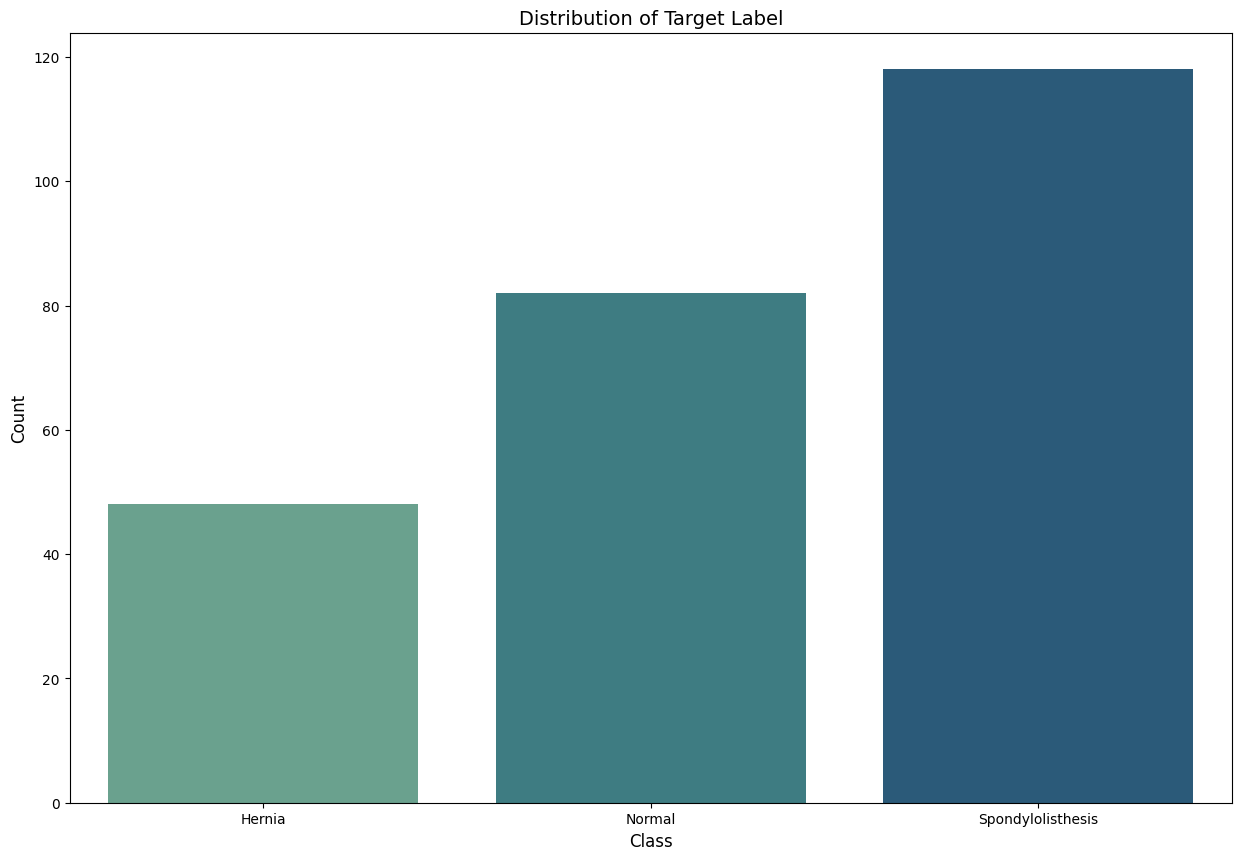

In [ ]:
plt.figure(figsize=(15, 10)) 

sns.countplot(x=y_train.sort_values(), data=x_train, palette='crest') 

plt.xlabel('Class', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.title('Distribution of Target Label', fontsize=14)

plt.show()

The Spondylolisthesis class represented the majority, while the Hernia class was the minority. This imbalance necessitates explicit handling during preprocessing, as a classifier trained on imbalanced data tends to be heavily biased toward predicting the majority class.

**Feature Distribution and Outlier Detection**

**Scatter plots**

Scatter plots comparing the index against feature values, colored by class, confirmed this observation. For `degree_spondylolisthesis`, several data points lay far above the general cluster, which clearly belonged to the Spondylolisthesis class. This extreme range of values and the presence of outliers in this particular feature is highly problematic for distance-based algorithms like K-Nearest Neighbors, as the distance metric would be overwhelmingly dominated by this single feature. This finding strongly validates the mandatory requirement for feature scaling.

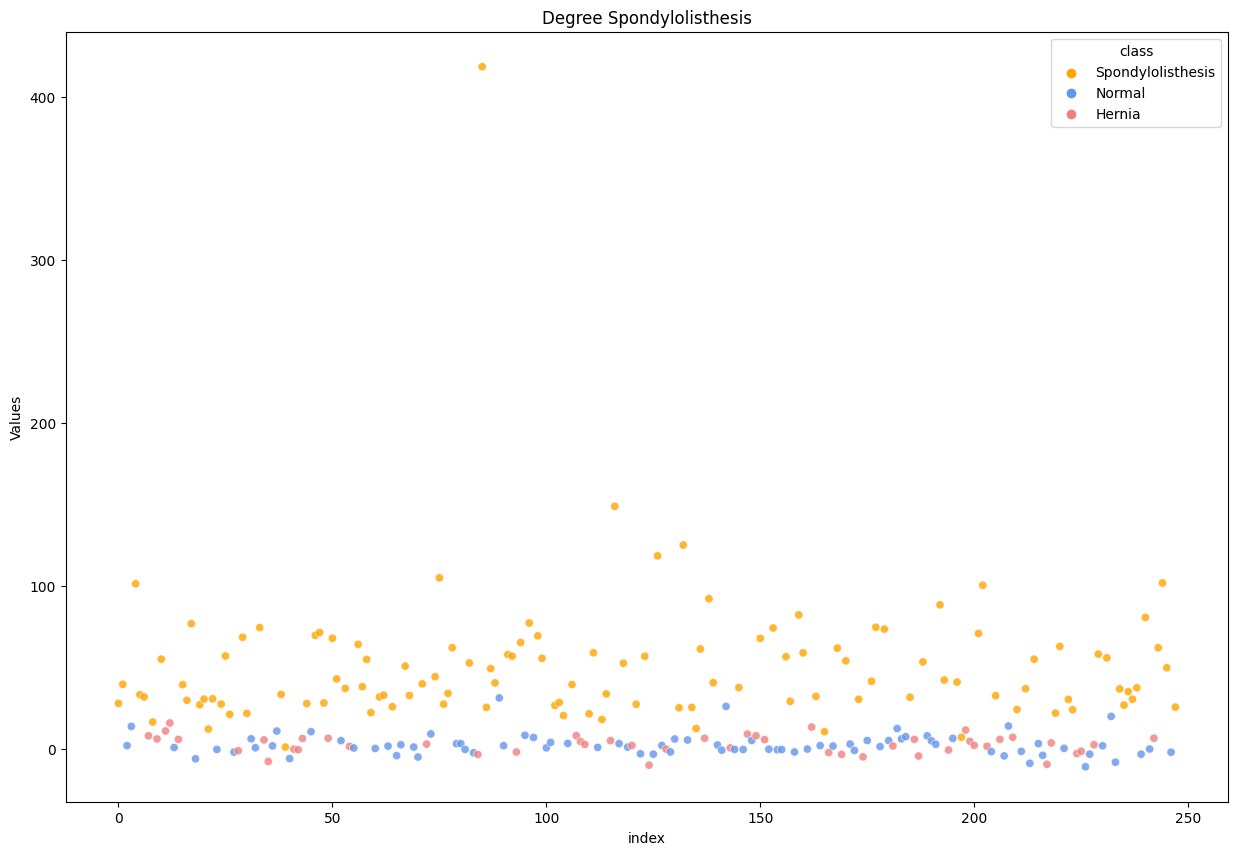

In [ ]:
plt.figure(figsize=(15, 10))
sns.scatterplot(x=np.arange(len(x_train)),
                y='degree_spondylolisthesis', 
                hue=y_train,
                data=x_train,
                palette={'Normal': 'cornflowerblue', 'Hernia': 'lightcoral', 'Spondylolisthesis': 'orange'},
                alpha=0.8)

plt.title('Degree Spondylolisthesis')
plt.xlabel('index')
plt.ylabel('Values')
plt.show()

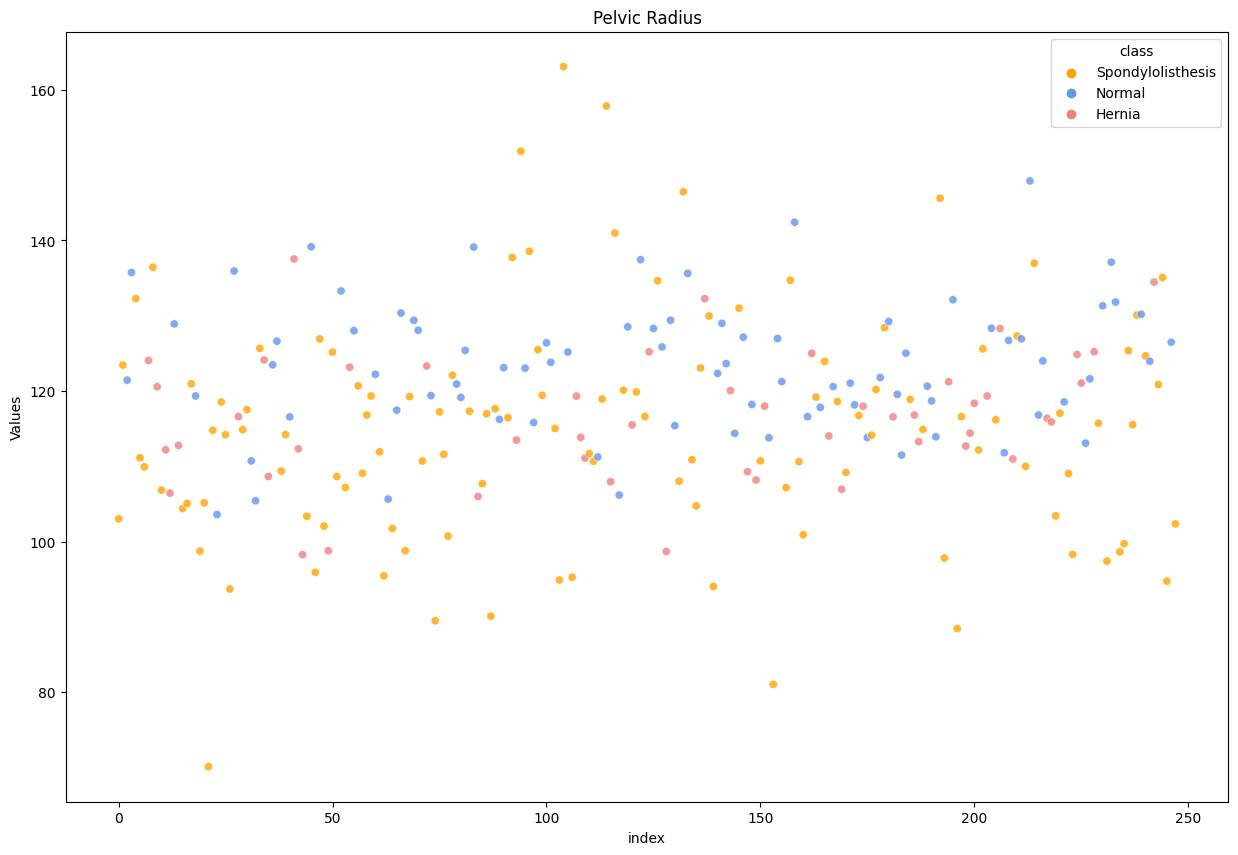

In [ ]:
plt.figure(figsize=(15, 10))
sns.scatterplot(x=np.arange(len(x_train)),
                y='pelvic_radius', 
                hue=y_train,
                data=x_train,
                palette={'Normal': 'cornflowerblue', 'Hernia': 'lightcoral', 'Spondylolisthesis': 'orange'},
                alpha=0.8)

plt.title('Pelvic Radius')
plt.xlabel('index')
plt.ylabel('Values')
plt.show()

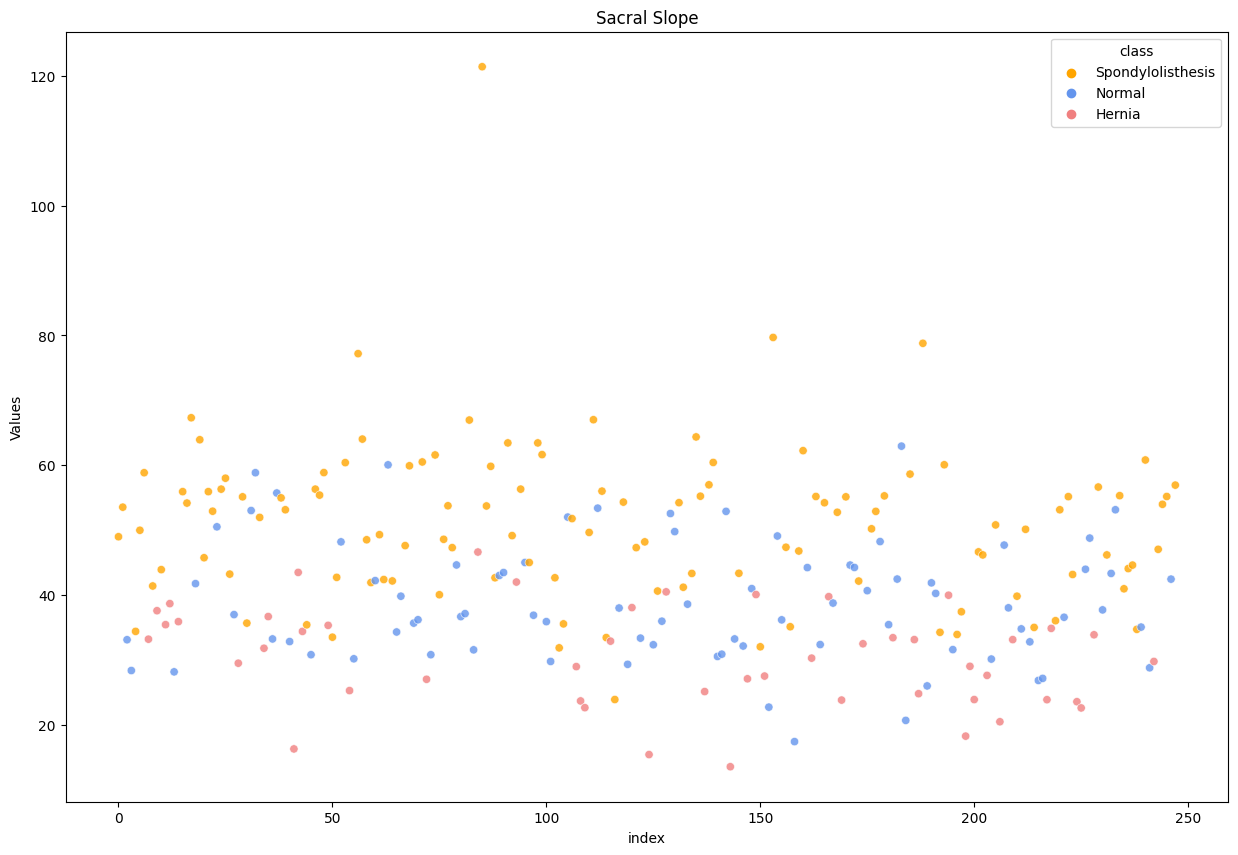

In [ ]:
plt.figure(figsize=(15, 10))
sns.scatterplot(x=np.arange(len(x_train)),
                y='sacral_slope', 
                hue=y_train,
                data=x_train,
                palette={'Normal': 'cornflowerblue', 'Hernia': 'lightcoral', 'Spondylolisthesis': 'orange'},
                alpha=0.8)

plt.title('Sacral Slope')
plt.xlabel('index')
plt.ylabel('Values')
plt.show()

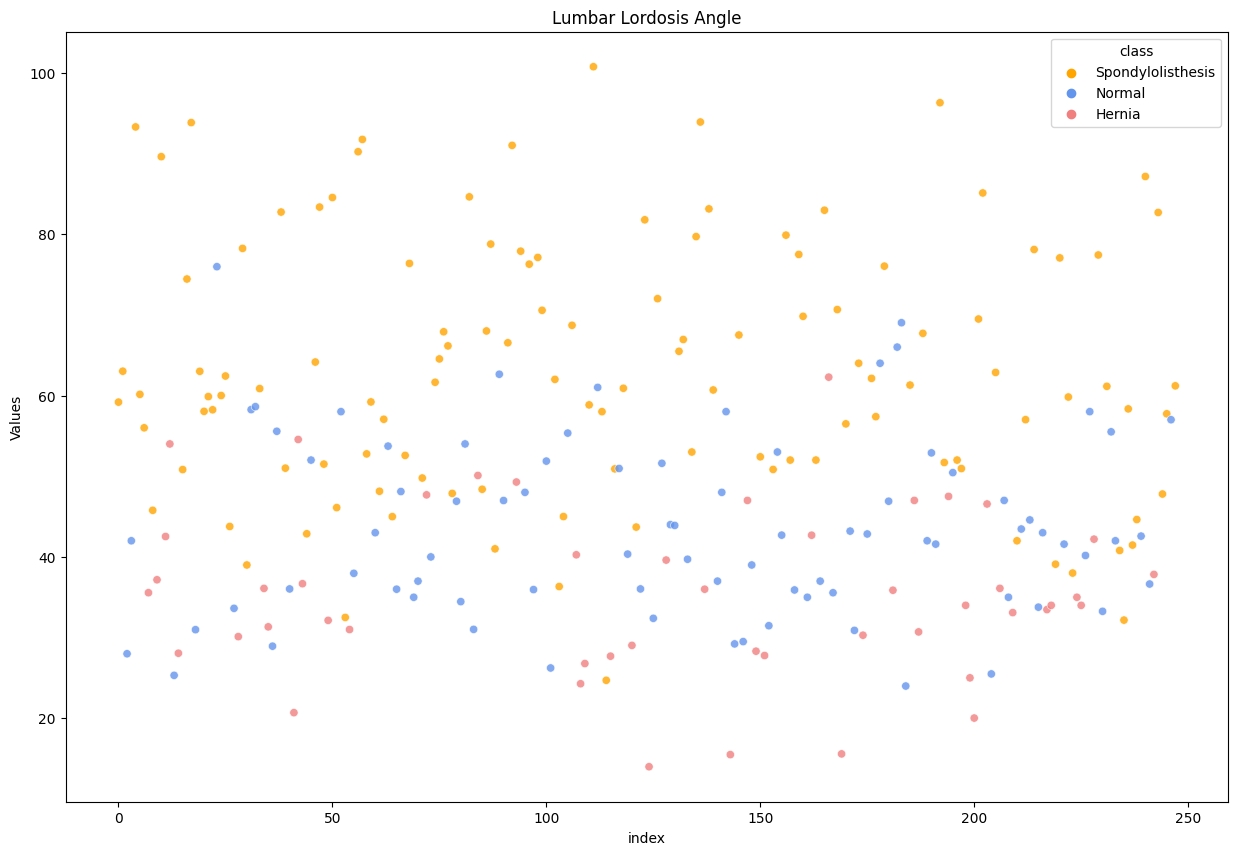

In [ ]:
plt.figure(figsize=(15, 10))
sns.scatterplot(x=np.arange(len(x_train)),
                y='lumbar_lordosis_angle', 
                hue=y_train,
                data=x_train,
                palette={'Normal': 'cornflowerblue', 'Hernia': 'lightcoral', 'Spondylolisthesis': 'orange'},
                alpha=0.8)

plt.title('Lumbar Lordosis Angle')
plt.xlabel('index')
plt.ylabel('Values')
plt.show()

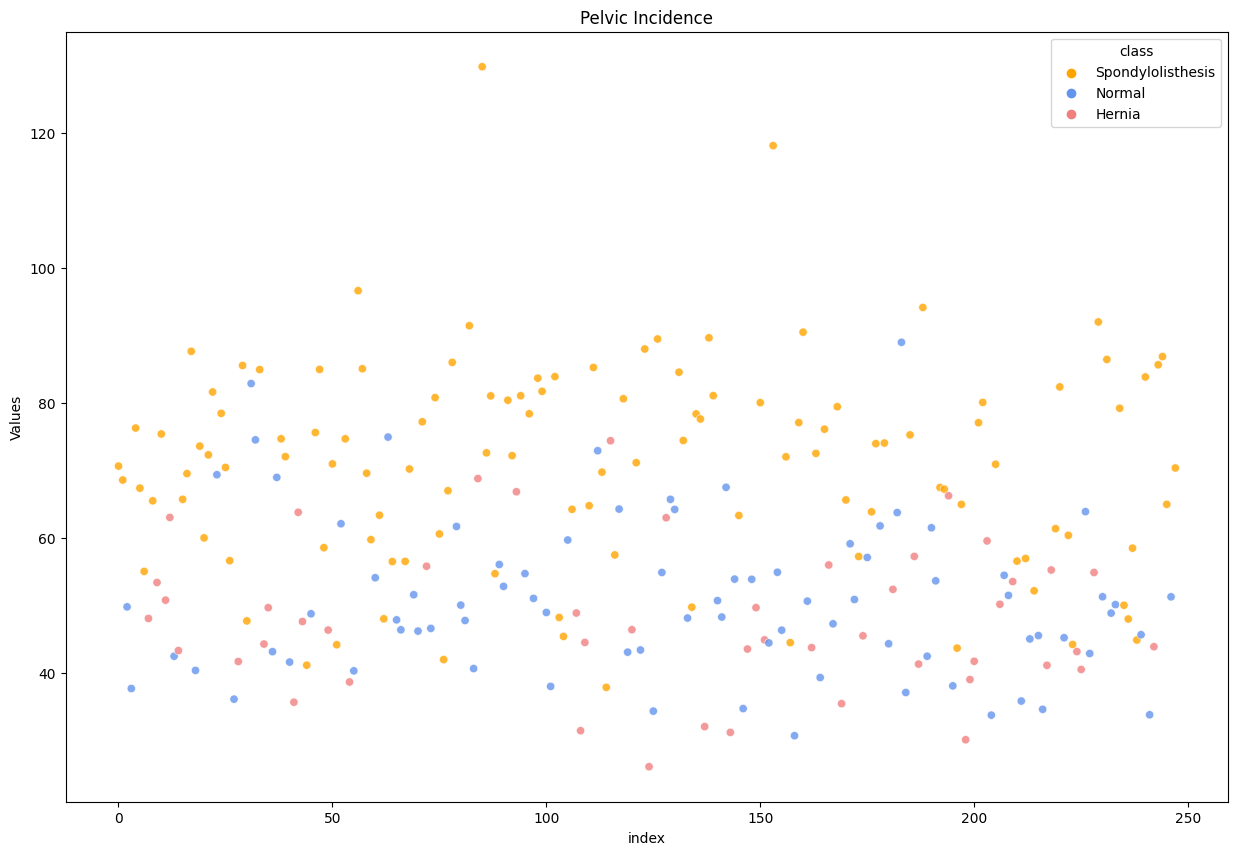

In [ ]:
plt.figure(figsize=(15, 10))
sns.scatterplot(x=np.arange(len(x_train)),
                y='pelvic_incidence', 
                hue=y_train,
                data=x_train,
                palette={'Normal': 'cornflowerblue', 'Hernia': 'lightcoral', 'Spondylolisthesis': 'orange'},
                alpha=0.8)

plt.title('Pelvic Incidence')
plt.xlabel('index')
plt.ylabel('Values')
plt.show()

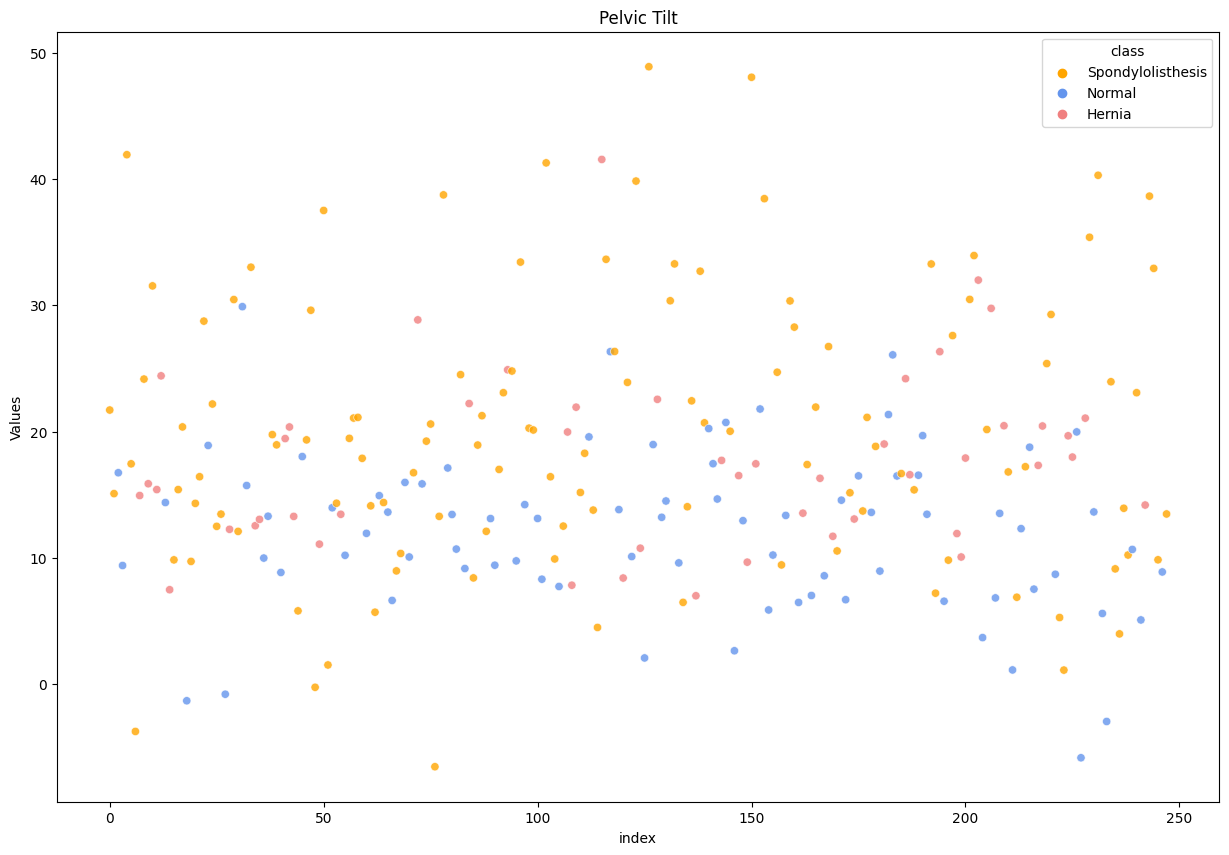

In [ ]:
plt.figure(figsize=(15, 10))
sns.scatterplot(x=np.arange(len(x_train)),
                y='pelvic_tilt', 
                hue=y_train,
                data=x_train,
                palette={'Normal': 'cornflowerblue', 'Hernia': 'lightcoral', 'Spondylolisthesis': 'orange'},
                alpha=0.8)

plt.title('Pelvic Tilt')
plt.xlabel('index')
plt.ylabel('Values')
plt.show()

**Histograms**

Histograms for the six features provided a visual understanding of their distributions. Most features, such as `pelvic_radius` and `sacral_slope`, exhibited distributions that are approximately normal or slightly skewed. However, the histogram for `degree_spondylolisthesis` indicated a heavily skewed distribution with a long tail extending toward high values, suggesting the presence of extreme outliers.

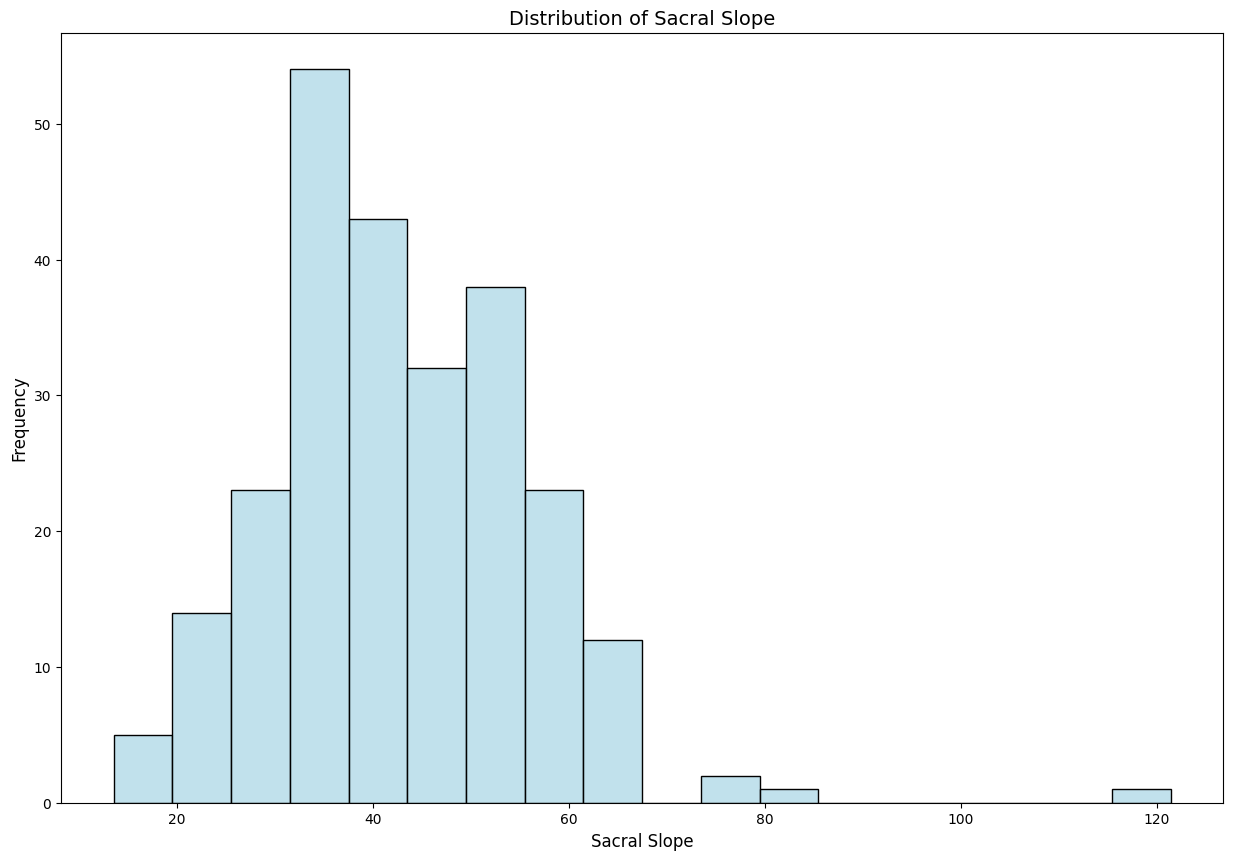

In [16]:
plt.figure(figsize=(15, 10))

sns.histplot(x=x_train['sacral_slope'], data=x_train, color='lightblue', kde=False)  # Use 'color'

plt.xlabel('Sacral Slope', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.title('Distribution of Sacral Slope', fontsize=14)
plt.show()

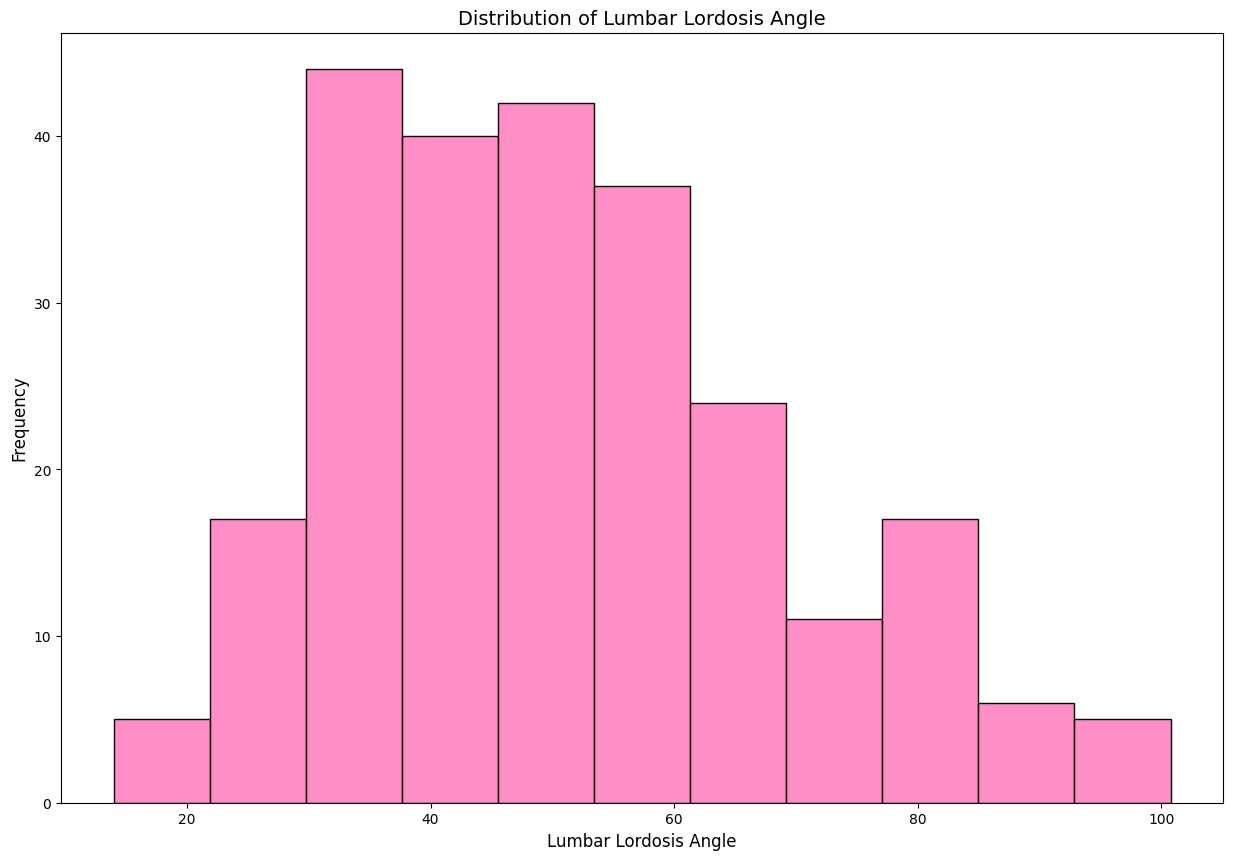

In [15]:
plt.figure(figsize=(15, 10))

sns.histplot(x=x_train['lumbar_lordosis_angle'], data=x_train, color='hotpink', kde=False)  # Use 'color'

plt.xlabel('Lumbar Lordosis Angle', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.title('Distribution of Lumbar Lordosis Angle', fontsize=14)

plt.show()

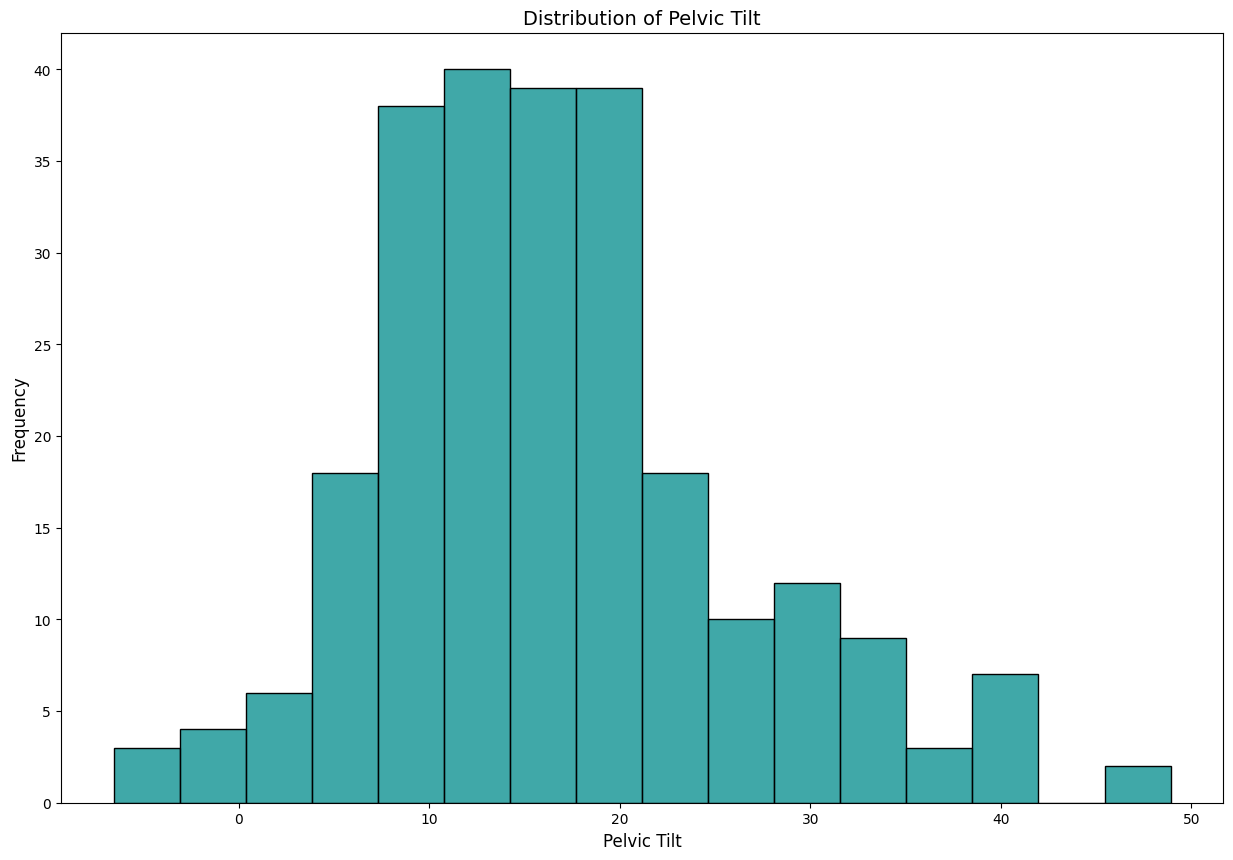

In [17]:
plt.figure(figsize=(15, 10))

sns.histplot(x=x_train['pelvic_tilt'], data=x_train, color='darkcyan', kde=False)  # Use 'color'

plt.xlabel('Pelvic Tilt', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.title('Distribution of Pelvic Tilt', fontsize=14)

plt.show()

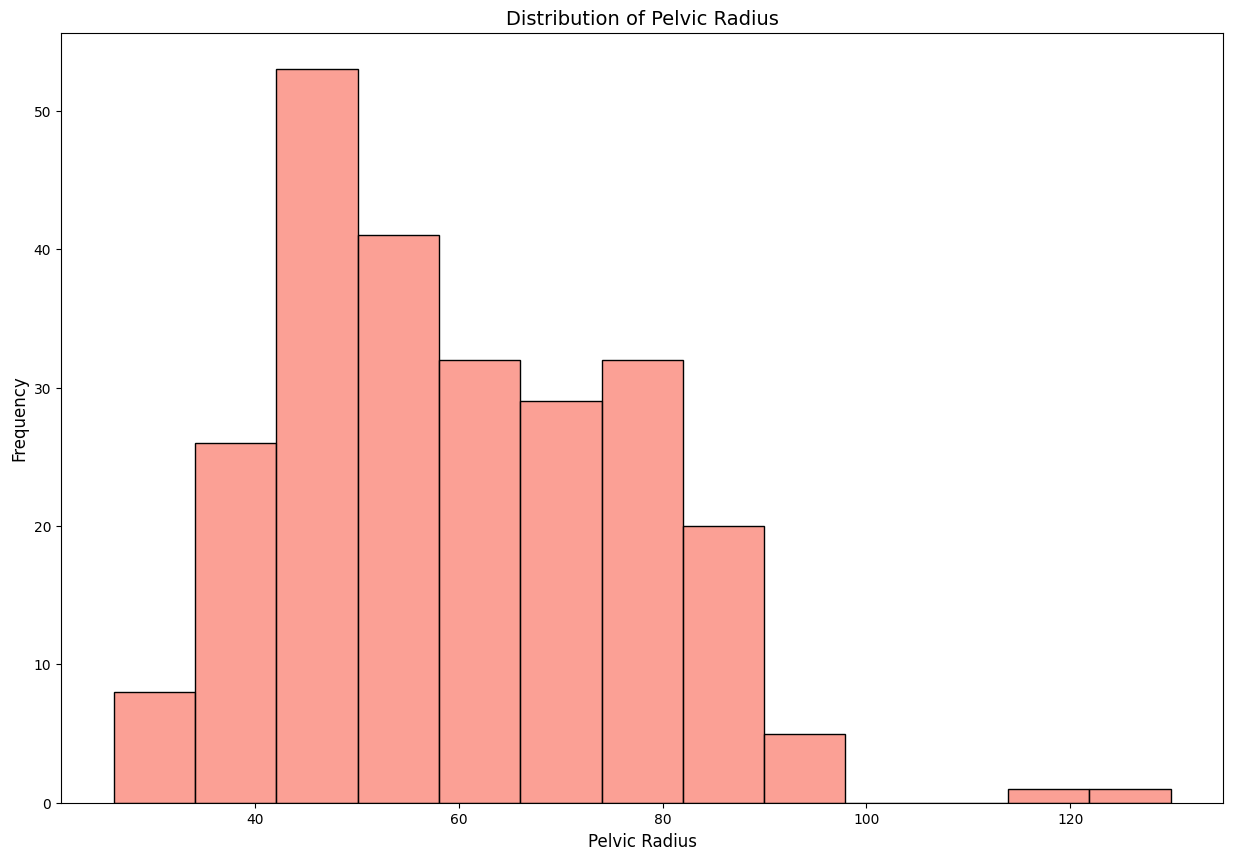

In [18]:
plt.figure(figsize=(15, 10))

sns.histplot(x=x_train['pelvic_incidence'], data=x_train, color='salmon', kde=False)  # Use 'color'

plt.xlabel('Pelvic Radius', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.title('Distribution of Pelvic Radius', fontsize=14)

plt.show()

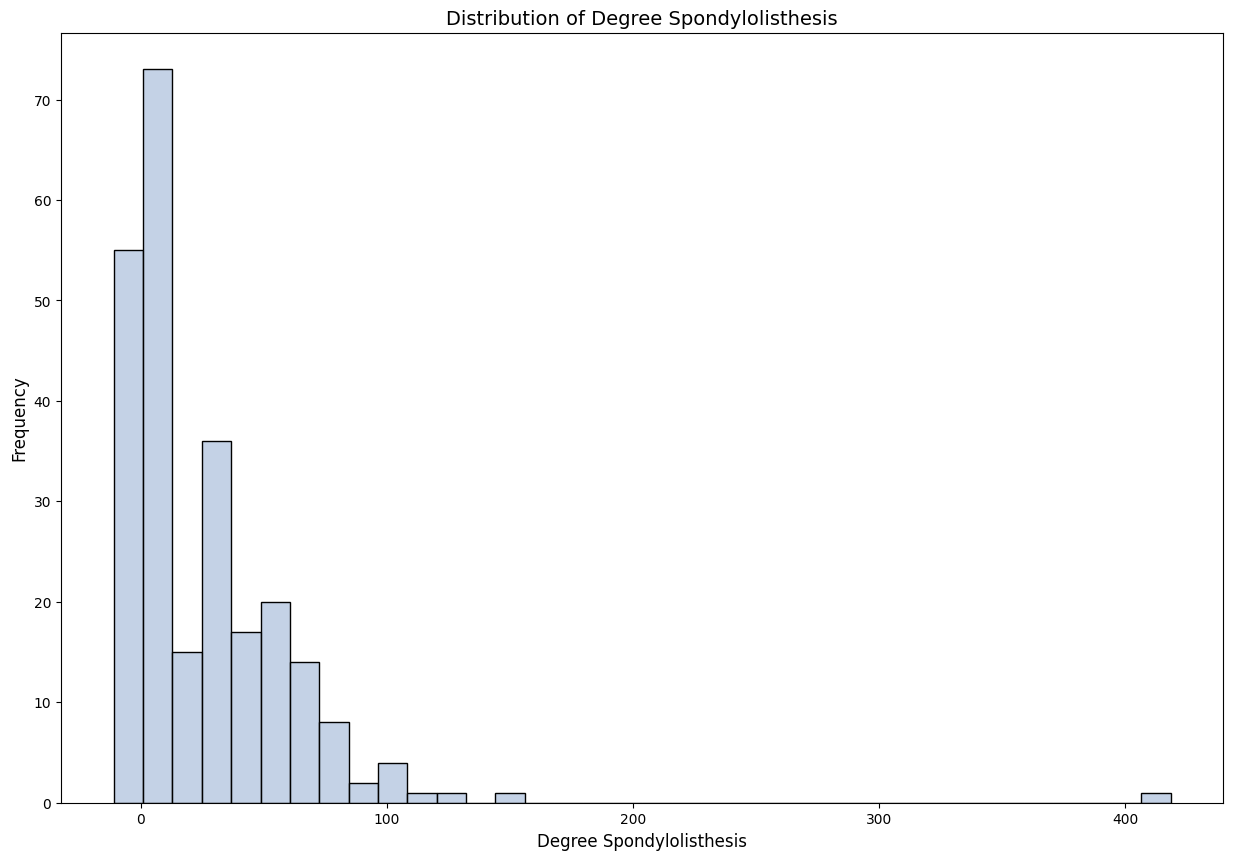

In [18]:
plt.figure(figsize=(15, 10))

sns.histplot(x=x_train['degree_spondylolisthesis'], data=x_train, color='lightsteelblue', kde=False)  # Use 'color'

plt.xlabel('Degree Spondylolisthesis', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.title('Distribution of Degree Spondylolisthesis', fontsize=14)

plt.show()

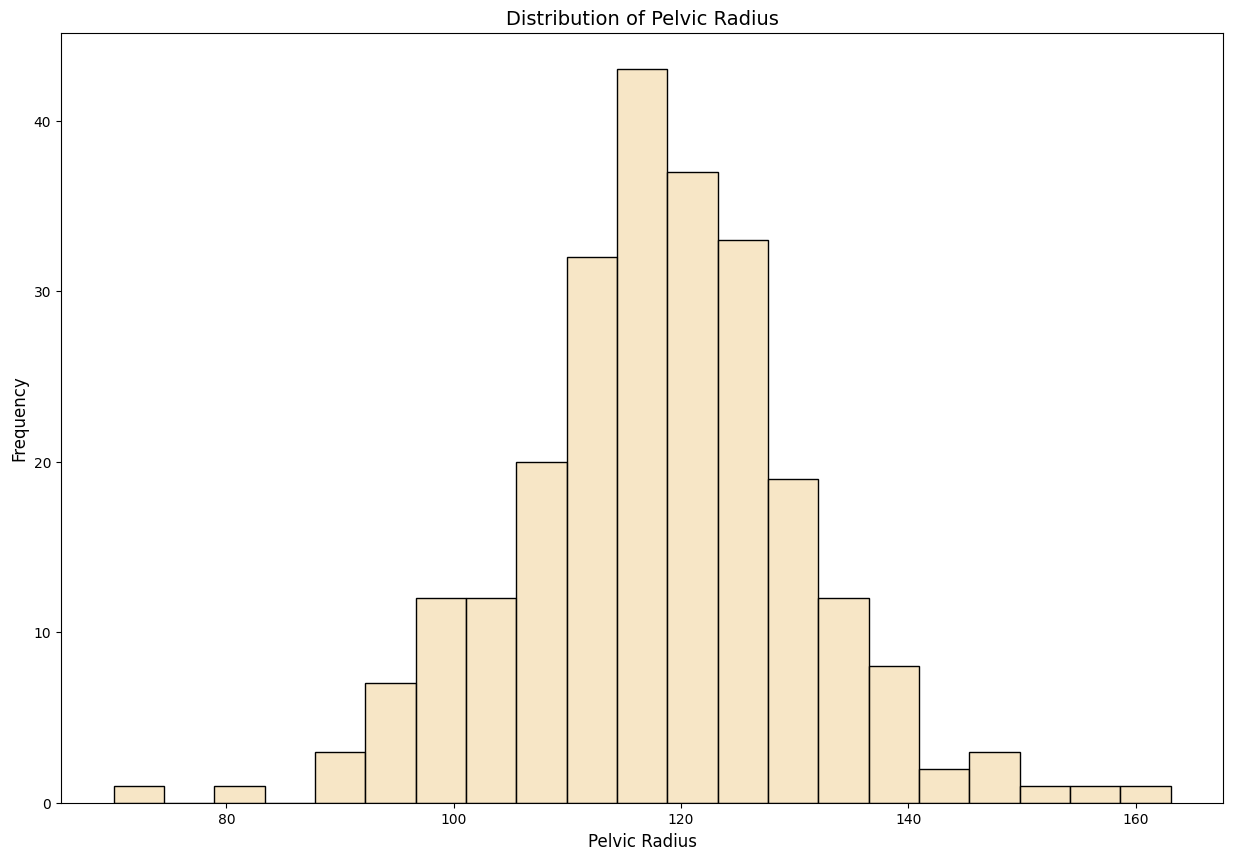

In [19]:
plt.figure(figsize=(15, 10))

sns.histplot(x=x_train['pelvic_radius'], data=x_train, color='wheat', kde=False)  # Use 'color'

plt.xlabel('Pelvic Radius', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.title('Distribution of Pelvic Radius', fontsize=14)

plt.show()

**Correlation Analysis**

The final exploratory step involved generating a correlation matrix after numerically encoding the target variable. This matrix illustrated the linear relationships between all features and the target. 

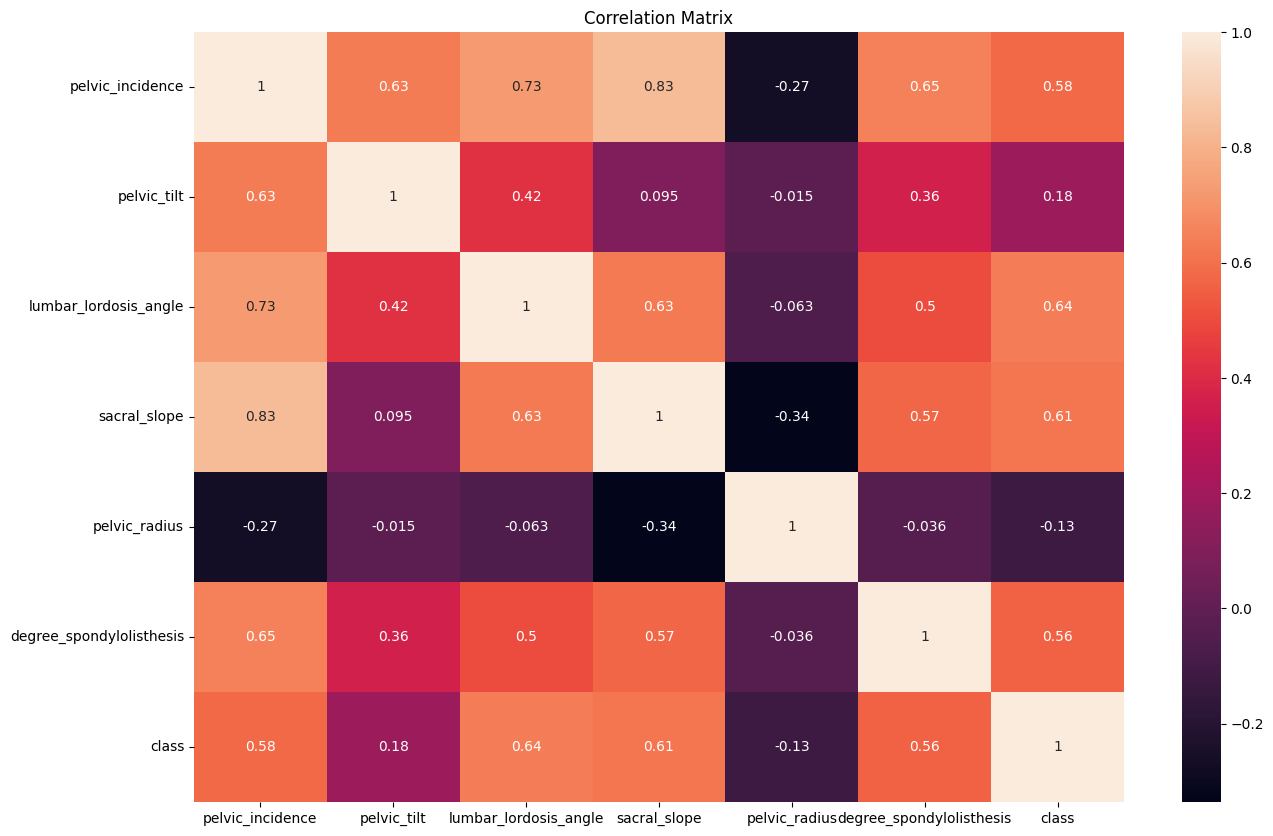

In [21]:
df_corr = pd.concat([x_train, y_train], axis=1) 

label = LabelEncoder()
df_corr['class'] = label.fit_transform(df_corr['class'])

correlation_matrix = df_corr.corr()
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True,cmap='rocket') 
plt.title('Correlation Matrix')
plt.show()

High correlations were observed between the target class and features like `pelvic_incidence, lumbar_lordosis_angle, and degree_spondylolisthesis`. Conversely, features like `pelvic_tilt and pelvic_radius` exhibited weaker correlations with the target. This analysis informed the initial feature selection step, where low-correlation columns were targeted for removal to streamline the model.

# Features Engineering

The data preprocessing stage involves a series of transformations essential for preparing the raw biomechanical measurements for effective use by the K-Nearest Neighbors (KNN) classifier. Since KNN relies on the concept of distance, all transformations are specifically designed to meet the algorithm's requirements.

In [22]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 248 entries, 126 to 102
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pelvic_incidence          248 non-null    float64
 1   pelvic_tilt               248 non-null    float64
 2   lumbar_lordosis_angle     248 non-null    float64
 3   sacral_slope              248 non-null    float64
 4   pelvic_radius             248 non-null    float64
 5   degree_spondylolisthesis  248 non-null    float64
dtypes: float64(6)
memory usage: 13.6 KB


In [23]:
x_train.describe()

,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis
count,248.000000,248.000000,248.000000,248.000000,248.000000,248.000000
mean,59.914854,16.881648,51.235758,43.033207,117.936050,25.361878
std,17.037413,9.518625,17.813783,13.258741,12.643236,38.261951
min,26.147921,-6.554948,14.000000,13.516568,70.082575,-11.058179
25%,46.339666,10.210614,36.919996,33.420565,110.826065,1.621685
50%,57.068628,15.563266,48.831327,42.182580,118.066181,11.166394
75%,72.581489,21.122489,61.731838,52.933180,125.247278,39.332866
max,129.834041,48.903653,100.744220,121.429566,163.071041,418.543082


In [24]:
x_train = x_train.drop(['pelvic_tilt','pelvic_radius'], axis = 1)
x_test = x_test.drop(['pelvic_tilt','pelvic_radius'], axis = 1)

**Feature Selection and Target Labels Encoding**

Initial data inspection revealed that all six feature columns were of the float64 data type and contained no missing values, simplifying the data preparation. The minimum, maximum, mean, and standard deviation values confirmed that the features possessed widely varying scales.

Based on preliminary correlation analysis, the features `pelvic_tilt and pelvic_radius` were identified as having lower predictive power relative to the target variable and were subsequently dropped from both the training and testing sets. This step aims to reduce potential noise and the dimensionality of the input space.

The target variable, representing the three spinal diagnoses, is a categorical label. Machine learning models require numerical input, necessitating the use of a `LabelEncoder`. This technique converts the textual class names into discrete integers: Hernia is mapped to 0, Normal to 1, and Spondylolisthesis to 2. This transformation ensures the output is compatible with multi-class classification metrics.

In [ ]:
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

In [ ]:
print("\nLabel mapping after encoding:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"{class_name} : {i}")


Label mapping after encoding:
Hernia : 0
Normal : 1
Spondylolisthesis : 2


In [27]:
x_train_withoutscale = x_train.copy()
y_train_withoutscale = y_train.copy()

**Data Normalization (Standardization)**

The varying scales of the remaining features—most notably the extreme range of `degree_spondylolisthesis` (from $\approx -11$ to $\approx 418$)—present a significant problem for the KNN algorithm. KNN computes the distance between data points, typically using the Euclidean distance formula. If features are not scaled, the distance metric will be overwhelmingly dominated by the feature with the largest magnitude, effectively rendering the contributions of lower-variance features negligible.

To mitigate this issue, `StandardScaler` is applied. Standardization transforms the data such that it has a mean of zero and a standard deviation of one (unit variance). This process ensures that all features contribute equally to the distance computation, which is critical for the success of KNN. The model is fitted only on the training data, and the learned parameters (mean and standard deviation) are then used to transform both the training and the test data.

In [ ]:
scaler = StandardScaler()
scaler = scaler.fit(x_train)
x_train = scaler.transform(x_train)

In [29]:
x_train_withoutpca = x_train.copy()
y_train_withoutpca = y_train.copy()

**Dimensionality Reduction (PCA)**

After standardization, Principal Component Analysis (PCA) is performed, reducing the feature space to two principal components (`n_components=2`). PCA is a linear dimensionality reduction technique that finds the directions (principal components) that maximize the variance in the data. By transforming the data onto these two components, two primary goals are achieved:

- Noise Reduction: Minor noise components are often discarded.
- Visualization: The resulting 2D space allows for the effective visual plotting of the data points, which is essential for understanding and interpreting the model's decision boundaries later in the project.

In [ ]:
pca = PCA(n_components=2)  
x_train = pca.fit_transform(x_train)
x_test = pca.transform(x_test)

**Oversampling (SMOTE)**

The initial analysis of the target distribution revealed a pronounced class imbalance, with Spondylolisthesis being the majority class and Hernia being the minority. If the model is trained on this skewed distribution, it will naturally develop a bias, leading to excellent accuracy on the majority class but poor performance (low recall) on the minority classes.

To counteract this bias, the Synthetic Minority Over-sampling Technique (SMOTE) is applied exclusively to the training data. SMOTE works by synthesizing new, artificial examples for the minority classes. It does this by taking existing minority data points and generating new points along the lines connecting the minority instance's nearest neighbors.


Class Distribution Before Over-Sampling:
Class
2    47.580645
1    33.064516
0    19.354839
Name: proportion, dtype: float64

Class Distribution After Over-Sampling:
Class
2    33.333333
1    33.333333
0    33.333333
Name: proportion, dtype: float64


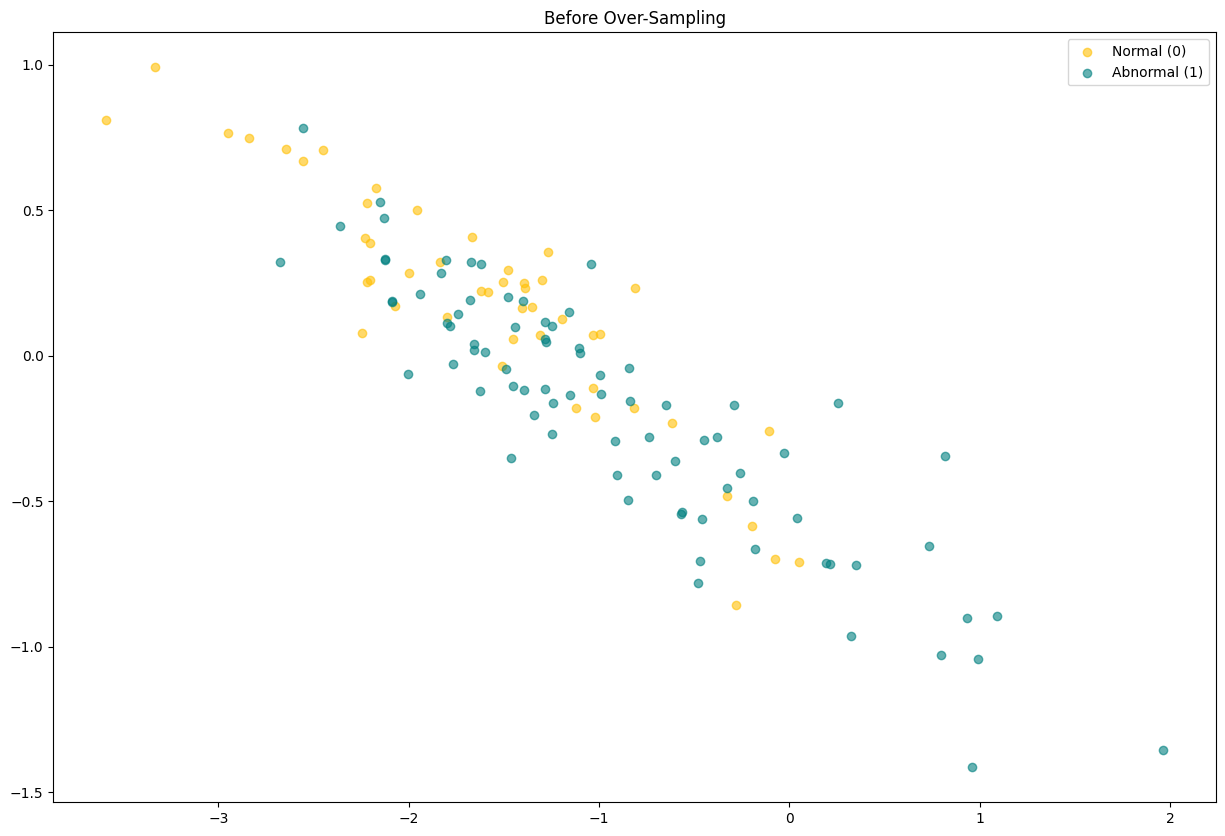

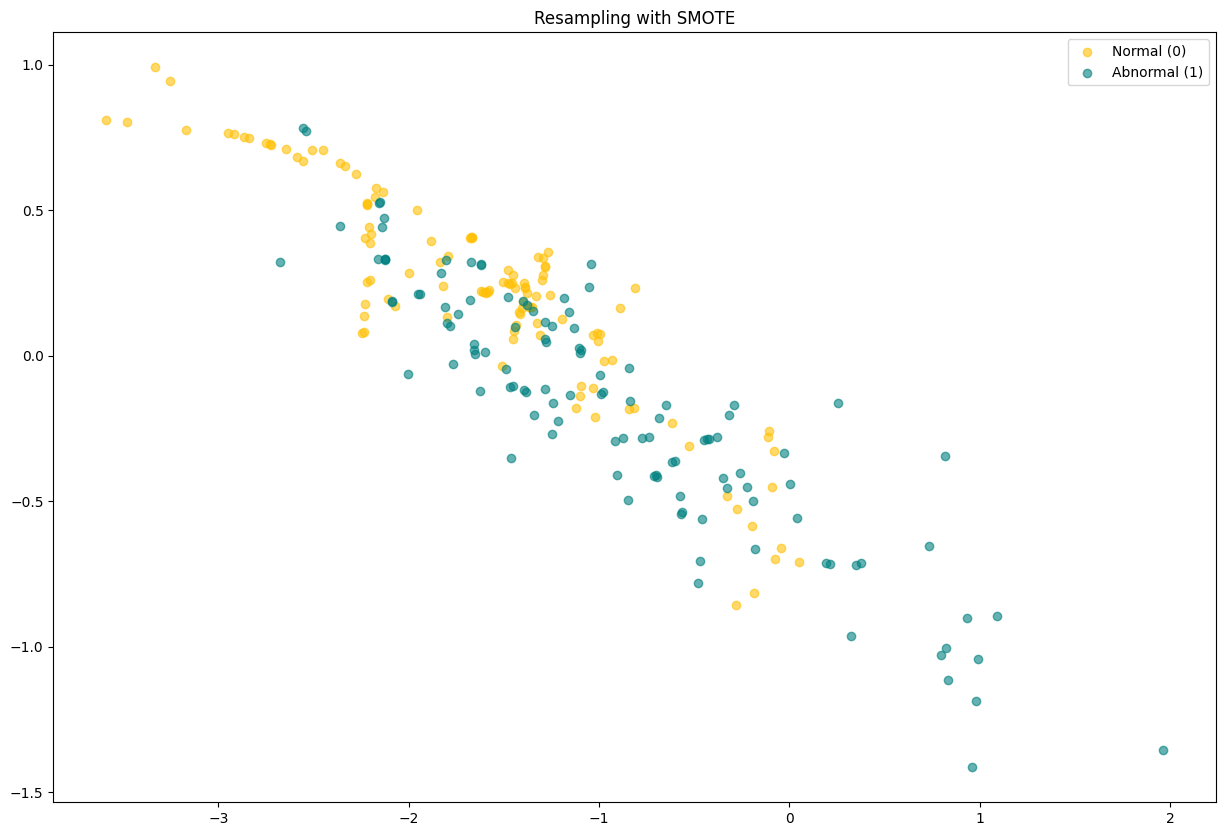

In [ ]:
sm = SMOTE(random_state=42)

x_resampled, y_resampled = sm.fit_resample(x_train, y_train)

y_train_series = pd.Series(y_train, name='Class')
y_resampled_series = pd.Series(y_resampled, name='Class')

print("\nClass Distribution Before Over-Sampling:")
print(y_train_series.value_counts(normalize=True) * 100)

print("\nClass Distribution After Over-Sampling:")
print(y_resampled_series.value_counts(normalize=True) * 100)

pca = PCA(n_components=2, random_state=42)

x_train_pca = pca.fit_transform(x_train)
x_resampled_pca = pca.transform(x_resampled)

df_before = pd.DataFrame(x_train_pca, columns=['PC1', 'PC2'])
df_before['Class'] = y_train

df_after = pd.DataFrame(x_resampled_pca, columns=['PC1', 'PC2'])
df_after['Class'] = y_resampled

color_map = {0: '#FFC107', 1: 'teal'}
label_map = {0: 'Normal', 1: 'Abnormal'}

plt.figure(figsize=(15, 10))
for label in np.unique(y_train):
    if label in color_map:
        plt.scatter(
            df_before[df_before['Class'] == label]['PC1'],
            df_before[df_before['Class'] == label]['PC2'],
            color=color_map[label],
            label=f'{label_map.get(label, str(label))} ({label})',
            alpha=0.6
        )
plt.xlabel('')
plt.ylabel('')
plt.title('Before Over-Sampling')
plt.legend(loc='best')
plt.show()

print()
plt.figure(figsize=(15, 10))
for label in np.unique(y_resampled):
    if label in color_map:
        plt.scatter(
            df_after[df_after['Class'] == label]['PC1'],
            df_after[df_after['Class'] == label]['PC2'],
            color=color_map[label],
            label=f'{label_map.get(label, str(label))} ({label})',
            alpha=0.6
        )
plt.xlabel('')
plt.ylabel('')
plt.title('Resampling with SMOTE')
plt.legend(loc='best')
plt.show()

The effect of SMOTE is highly visible in the class distribution:

- Before SMOTE: The distribution shows the majority class at approximately $47.6%$, the next at $33.1%$, and the minority class at $19.4%$.
- After SMOTE: The oversampling successfully balances the classes, resulting in an equal distribution where each of the three classes occupies $33.33%$ of the training data.

The scatter plots comparing the 2D PCA representation of the data Before Over-Sampling and Resampling with SMOTE illustrate the practical impact of this technique.

- The Before Over-Sampling plot visually confirms the imbalance, showing a significantly denser cluster for the majority class compared to the sparse clusters of the minority classes in the PCA space.
- The Resampling with SMOTE plot demonstrates a uniform density across all three class clusters. This visual confirmation indicates that SMOTE has successfully introduced synthetic data points, making the boundaries of all three classes roughly equally represented in the training process. This balance is fundamental for ensuring the KNN classifier learns a decision boundary that is fair to all diagnosis classes.

# Model Training, Experiments, and Visaulization

The modeling phase involves establishing baseline performance for the K-Nearest Neighbors (KNN) and Radius Neighbors Classifiers, visualizing their initial decision boundaries, and systematically optimizing the best-performing model.

**Baseline Models and Cross-Validation**

The project utilizes two primary distance-based classification algorithms:
- K-Neighbors Classifier ($KNC$): This method classifies a new data point by a majority vote of its $K$ nearest neighbors, where $K$ is a hyperparameter. Its strength lies in its non-parametric nature, making no assumptions about the underlying data distribution.
- Radius Neighbors Classifier ($RNC$): Instead of using a fixed number of neighbors $K$, RNC classifies a point based on all neighbors falling within a predefined radius $R$. This approach is often more robust when the data density varies, though it requires careful selection of the radius parameter.

Both models were evaluated using 10-fold cross-validation on the scaled training data. Cross-validation is a robust technique for assessing a model's performance stability and generalization ability by splitting the training data into ten segments, training on nine, and testing on the remaining one, repeating this process ten times.

The $KNC$ achieved an average cross-validation accuracy of approximately $0.7503$, demonstrating stable performance across the folds. The $\text{RNC}$ achieved a slightly lower average accuracy of approximately $0.7017$. Based on this preliminary assessment, the K-Neighbors Classifier is identified as the superior base model and is prioritized for further hyperparameter tuning.

In [ ]:
ml_models = [
    ("KNeighborsClassifier", KNeighborsClassifier()),
    ("RadiusNeighborsClassifier", RadiusNeighborsClassifier(outlier_label='most_frequent')),  # Handle outliers
]

for model in ml_models:
    print(model[0]+": ")
    model[1].fit(x_train, y_train)
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    cv = cross_val_score(model[1], x_train, y_train, cv=10, scoring='accuracy')
    print("\tK-Fold Cross-Validation:", cv)
    print('-'*100)
    print(f'\tAverage K-Fold Cross-Validation: {cv.mean()}')
    print('-'*100)

KNeighborsClassifier: 
	K-Fold Cross-Validation: [0.76       0.68       0.8        0.76       0.8        0.68
 0.68       0.76       0.83333333 0.75      ]
----------------------------------------------------------------------------------------------------
	Average K-Fold Cross-Validation: 0.7503333333333333
----------------------------------------------------------------------------------------------------
RadiusNeighborsClassifier: 
	K-Fold Cross-Validation: [0.6        0.6        0.72       0.8        0.76       0.68
 0.76       0.68       0.66666667 0.75      ]
----------------------------------------------------------------------------------------------------
	Average K-Fold Cross-Validation: 0.7016666666666667
----------------------------------------------------------------------------------------------------


**Decision Boundary Visualization**

To understand how the two models differentiate between the three spinal conditions (after they have been reduced to two principal components), their decision boundaries are plotted.The visualization plots the data points in the 2D plane defined by Principal Component 1 (PC1) and Principal Component 2 (PC2). The colored regions represent the classification prediction for every point in that space.

- K-Neighbors Classifier Decision Boundary: The boundary for the $KNC$ appears relatively smooth and flexible. The decision surfaces closely track the clusters of data points in the reduced space, reflecting the local nature of the KNN algorithm, where the classification is dictated by immediate neighbors.
- Radius Neighbors Classifier Decision Boundary: The boundary for the $RNC$ appears fragmented and less defined in certain low-density areas. This behavior is characteristic of the $RNC$, as regions lacking sufficient neighbors within the fixed radius $R$ result in uncertain or default classifications.

The visual confirmation reinforced the numerical cross-validation, suggesting that the $KNC$'s approach of fixing the number of neighbors $K$ provided a more stable and coherent classification surface for this dataset.

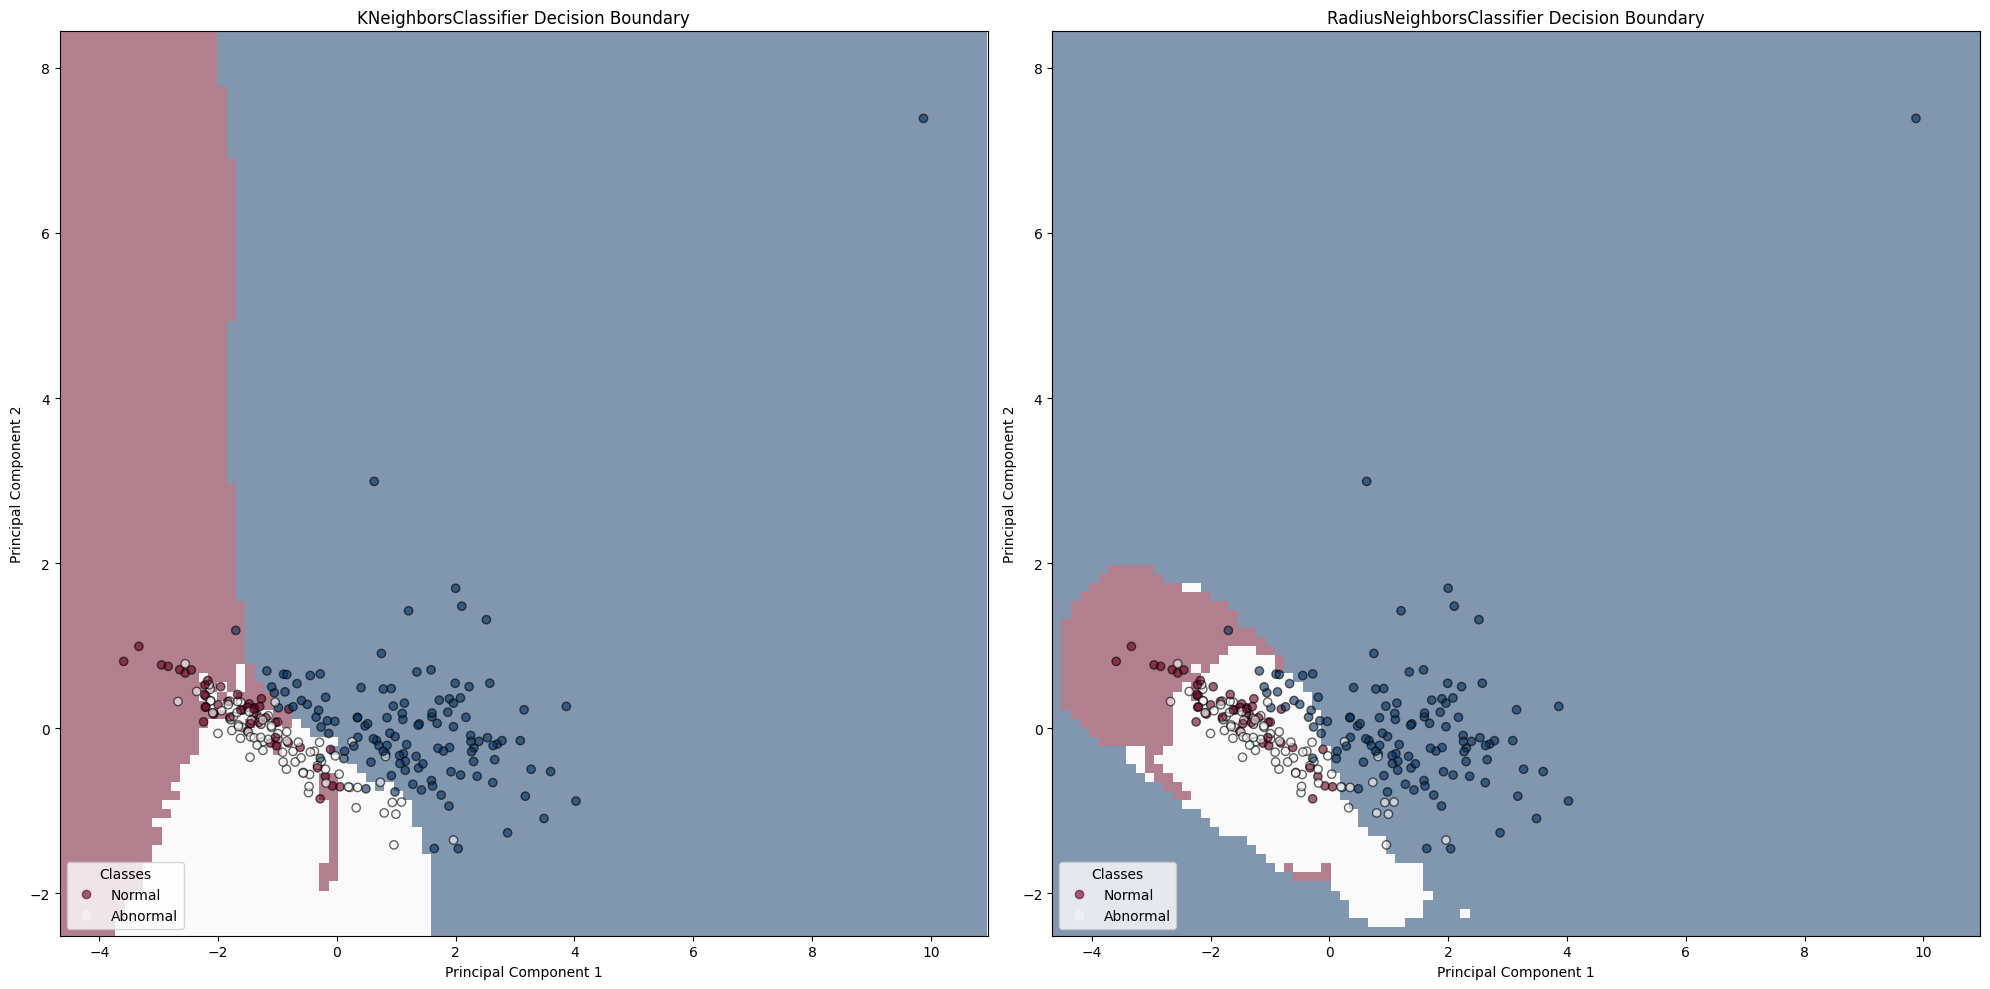

In [ ]:
h = 0.02
x_range = x_train_pca[:, 0].max() - x_train_pca[:, 0].min()
y_range = x_train_pca[:, 1].max() - x_train_pca[:, 1].min()
padding_x = 0.05 * x_range
padding_y = 0.05 * y_range
x_min, x_max = x_train_pca[:, 0].min() - padding_x, x_train_pca[:, 0].max() + padding_x
y_min, y_max = x_train_pca[:, 1].min() - padding_y, x_train_pca[:, 1].max() + padding_y
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

fig, axs = plt.subplots(ncols=2, figsize=(20, 10))

class_names = ['Normal', 'Abnormal']

for (model_name, model), ax in zip(ml_models, axs):
    model.fit(x_train_pca, y_train)

    disp = DecisionBoundaryDisplay.from_estimator(
        model,
        x_train_pca,
        response_method="predict",
        plot_method="pcolormesh",
        xlabel="Principal Component 1",
        ylabel="Principal Component 2",
        shading="auto",
        alpha=0.5,
        ax=ax,
        cmap=plt.cm.RdBu
    )

    scatter = ax.scatter(
        x_train_pca[:, 0],
        x_train_pca[:, 1],
        c=y_train,
        cmap=plt.cm.RdBu,
        edgecolors="k",
        alpha=0.6
    )

    ax.legend(
        scatter.legend_elements()[0],
        class_names,
        loc="lower left",
        title="Classes",
    )

    ax.set_title(f"{model_name} Decision Boundary")

plt.tight_layout()
plt.show()

**Caching and Hyperparameter Optimization**

Optimization efforts focus on finding the best value for $K$ in the K-Neighbors Classifier. A computationally efficient technique is employed using the KNeighborsTransformer within a Pipeline to cache the nearest neighbors graph.

**K-Neighbors Classifier Optimization**

The nearest neighbors graph, representing the distances between all training samples, is computed once and stored. Subsequent parameter searches, conducted using GridSearchCV across $K$ values from $1$ to $50$, reuse this cached graph.

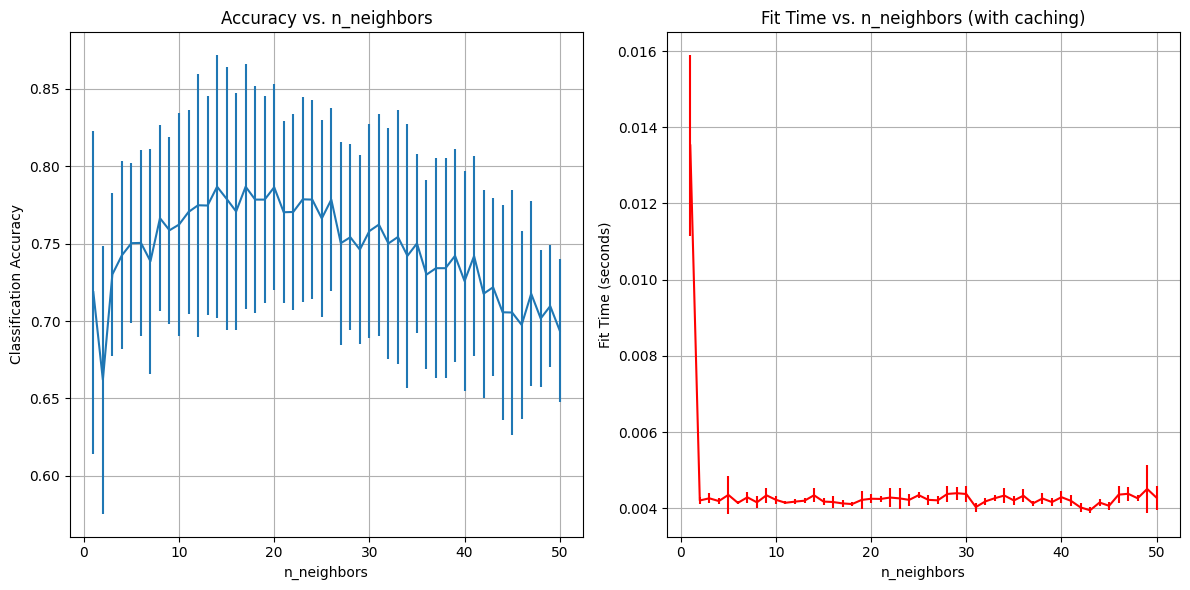


Best Parameters: {'classifier__n_neighbors': 14}
Best Cross-Validation Accuracy: 0.7868333333333333


In [ ]:
n_neighbors_list = list(range(1, 51))

graph_model = KNeighborsTransformer(n_neighbors=max(n_neighbors_list), mode="distance")
classifier_model = KNeighborsClassifier(metric="precomputed")

with TemporaryDirectory(prefix="sklearn_graph_cache_") as tmpdir:
    full_model = Pipeline(
        steps=[("graph", graph_model), ("classifier", classifier_model)],
        memory=tmpdir
    )

    param_grid = {"classifier__n_neighbors": n_neighbors_list}

    grid_model = GridSearchCV(full_model, param_grid, cv=10, scoring='accuracy')
    grid_model.fit(x_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].errorbar(
    x=n_neighbors_list,
    y=grid_model.cv_results_["mean_test_score"],
    yerr=grid_model.cv_results_["std_test_score"],
)
axes[0].set_xlabel("n_neighbors")
axes[0].set_ylabel("Classification Accuracy")
axes[0].set_title("Accuracy vs. n_neighbors")
axes[0].grid(True)

axes[1].errorbar(
    x=n_neighbors_list,
    y=grid_model.cv_results_["mean_fit_time"],
    yerr=grid_model.cv_results_["std_fit_time"],
    color="r",
)
axes[1].set_xlabel("n_neighbors")
axes[1].set_ylabel("Fit Time (seconds)")
axes[1].set_title("Fit Time vs. n_neighbors (with caching)")
axes[1].grid(True)

fig.tight_layout()
plt.show()

print("\nBest Parameters:", grid_model.best_params_)
print("Best Cross-Validation Accuracy:", grid_model.best_score_)

- Accuracy vs. `n_neighbors`: The plot illustrating classification accuracy against the number of neighbors revealed a clear trend: accuracy initially rose rapidly as $K$ increased from $1$ (high variance) and then stabilized before beginning a slow decline (increasing bias). The peak performance was achieved at `n_neighbors = 14`, yielding a best cross-validation accuracy of approximately $0.7868$.
- Fit Time vs. `n_neighbors` (with caching): The plot showed a nearly flat line for the fit time across all values of $K$. This confirms the success of the caching strategy, as the computational time required to test each new $K$ value was minimal and constant, dramatically speeding up the tuning process.

**Radius Neighbors Classifier Optimization (Proxy Method)**

An attempt was made to optimize the Radius Neighbors Classifier using a similar caching approach. However, since the primary $RNC$ model does not directly benefit from the KNeighborsTransformer (as it relies on radius, not a fixed $K$), the experiment used the $KNC$ as a proxy to test the efficiency of the caching pipeline structure itself with different parameters.

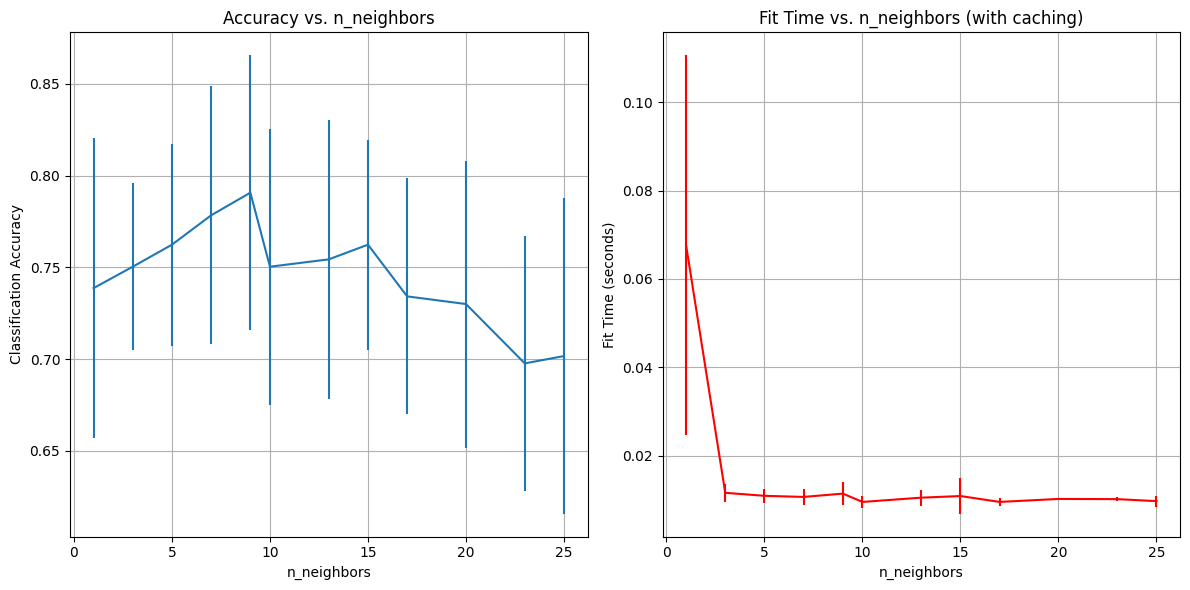


Best Parameters: {'classifier__n_neighbors': 9}
Best Cross-Validation Accuracy: 0.7906666666666667


In [ ]:
n_neighbors_list = [1, 3, 5, 7, 9, 10, 13, 15, 17, 20, 23, 25]

graph_model = KNeighborsTransformer(n_neighbors=max(n_neighbors_list), mode="distance")
classifier_model = KNeighborsClassifier()

with TemporaryDirectory(prefix="sklearn_graph_cache_") as tmpdir:
    full_model = Pipeline(
        steps=[("scaler", StandardScaler()), ("graph", graph_model), ("classifier", classifier_model)],
        memory=tmpdir
    )

    param_grid = {"classifier__n_neighbors": n_neighbors_list}

    grid_model = GridSearchCV(full_model, param_grid, cv=10, scoring='accuracy', n_jobs=-1)
    grid_model.fit(x_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].errorbar(
    x=n_neighbors_list,
    y=grid_model.cv_results_["mean_test_score"],
    yerr=grid_model.cv_results_["std_test_score"],
)
axes[0].set_xlabel("n_neighbors")
axes[0].set_ylabel("Classification Accuracy")
axes[0].set_title("Accuracy vs. n_neighbors")
axes[0].grid(True)

axes[1].errorbar(
    x=n_neighbors_list,
    y=grid_model.cv_results_["mean_fit_time"],
    yerr=grid_model.cv_results_["std_fit_time"],
    color="r",
)
axes[1].set_xlabel("n_neighbors")
axes[1].set_ylabel("Fit Time (seconds)")
axes[1].set_title("Fit Time vs. n_neighbors (with caching)")
axes[1].grid(True)

fig.tight_layout()
plt.show()

print("\nBest Parameters:", grid_model.best_params_)
print("Best Cross-Validation Accuracy:", grid_model.best_score_)

The $KNC$ within the caching pipeline confirmed its best performance at `n_neighbors = 9` with a cross-validation accuracy of approximately $0.7907$. The fit time plot remained flat, further validating the utility of neighbor caching for efficient hyperparameter exploration in distance-based models.The final optimized model selected for subsequent evaluation is the K-Neighbors Classifier with $K=14$, as determined by the exhaustive grid search.

**Hyperparameters Tuning**

The overarching goal of this machine learning process is to determine the optimal configuration—the hyperparameters—that maximizes the model's estimated performance on unseen data. Unlike model parameters which are learned during training, hyperparameters must be set beforehand. The code employs Optuna, a library that uses sequential model-based optimization to efficiently explore the search space.

The specific sampling strategy used is the Tree-structured Parzen Estimator ($TPE$). $TPE$ builds a probability model of the objective function and uses this model to propose new trials that are likely to yield better results, offering a more efficient alternative to exhaustive or random searches. Each optimization study is configured to $maximize$ the objective function, which is the mean cross-validation ($CV$) accuracy. $CV$ ensures the performance metric is stable and not reliant on a single train-test split.

**The K-Nearest Neighbors ($KNN$) Algorithm**

K-Nearest Neighbors is a non-parametric, instance-based learning algorithm that classifies a data point based on the majority class of its $k$ closest neighbors. The objective function, objective_knn, searches across several critical hyperparameters:
- $n_neighbors$: The value of $k$, representing the fixed number of neighbors considered for classification. The search range spans from $1$ to $50$ to find the optimal neighborhood size.
- $weights$: Defines the influence of each neighbor. The uniform option gives all neighbors equal weight, while distance weights neighbors proportional to the inverse of their distance from the query point.
- $p$ (Minkowski distance parameter): Controls the distance metric used for proximity calculation. Setting $p=1$ corresponds to the Manhattan distance ($\mathrm{L}_1$ norm), and $p=2$ corresponds to the Euclidean distance ($\mathrm{L}_2$ norm).

**Radius Neighbors Classifier ($RNC$)**

The Radius Neighbors Classifier is an extension of $KNN$ where the size of the neighborhood is determined by a fixed distance $radius$ instead of a fixed count of $k$. All data points within this defined radius are considered neighbors. The objective_radius function focuses on tuning the continuous parameter $radius$ using logarithmic sampling across a defined range.

The $RNC$ model addresses classification for points outside the defined radius by setting the `outlier_label` parameter to `most_frequent`. This critical setting ensures that if a query point has no neighbors within the specified radius (common in sparse data regions), it is still assigned a class based on the most common class in the entire training set.

**K-Nearest Neighbors (KNN) Classifier and the Radius Neighbors Classifier (RNC) Hyperparameters**

**K-Nearest Neighbors (KNN) Classifier Hyperparameters**

The KNN classifier is a lazy learning algorithm that classifies a new data point based on the majority class of its $K$ closest neighbors.

**1. `n_neighbors` (K)**

This is the most critical parameter and represents the actual number of neighbors the model considers.
- Meaning: When predicting the class for a new point, the algorithm finds the $K$ training points closest to it and uses their class labels to vote.
- Small $K$ (e.g., $K=1$): The decision boundary becomes highly local and jagged. The model is very flexible and sensitive to noise or outliers, often leading to overfitting (high variance).
- Large $K$: The decision boundary becomes smoother, as the model averages the votes over a wider area. This makes the model more robust to noise, but if $K$ is too large, it can lead to underfitting (high bias), as it fails to capture local patterns.

**2. `weights`**

This hyperparameter determines how much influence each of the $K$ neighbors has on the final classification decision.
- Meaning: It specifies the weighting scheme for the neighbors' votes.
- uniform: Every neighbor, regardless of its distance from the query point, casts an equal vote (a simple majority vote).
- distance: Neighbors that are closer to the query point have a proportionally higher weight on the vote than neighbors farther away. This often yields better results by giving more importance to the most relevant local data.

**3. `metric and p`**

These parameters define how "distance" is measured between points.
- Meaning: metric defines the distance function (e.g., Euclidean, Manhattan), and p is the power parameter for the common Minkowski distance.
- Setting $p=2$ makes the metric the Euclidean distance (straight-line distance), which is the most common default.
- Setting $p=1$ makes the metric the Manhattan distance (or city-block distance), which measures distance along the axes.
- The choice of metric is important because it changes which training points are considered the "nearest" neighbors, drastically altering the classification results, especially in high-dimensional space.

**Radius Neighbors (RNC) Classifier Hyperparameters**

The RNC uses a fundamentally different approach: it classifies a new point based on all neighbors that fall within a fixed distance (radius) $R$.

**1. `radius (R)`**

This is the central parameter, defining the scope of the neighborhood by distance rather than count.
- Meaning: The maximum distance a training point can be from the new query point to be considered a neighbor.
- Small radius: The neighborhood is small and localized. If the radius is too small, a query point might have zero neighbors, preventing a prediction. This tends towards high variance.
- Large radius: The neighborhood is large and encompasses many training points. If the radius is too large, most query points will include almost all training data, leading to over-generalization and underfitting.

**2. `weights`**

This parameter works exactly the same as in the KNN classifier, allowing you to use either a uniform weight (equal votes) or a distance weight (closer points vote more strongly) for all points within the defined radius.

**3. `outlier_label`**

This is a hyperparameter unique to RNC due to its radius-based approach.
- Meaning: It specifies the label to be assigned to a new data point that falls in a sparse area and has no neighbors within the defined radius.
- If the RNC finds zero neighbors for a point, you can explicitly label it as an 'outlier' or assign a default class, instead of letting the algorithm raise an error. This is crucial for handling isolated data points or outliers present in the test set.Both KNN and RNC require careful tuning of their respective primary parameters—$K$ for KNN and $R$ for RNC—to balance the trade-off between bias and variance.

In [ ]:
def objective_knn(trial):
    params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 1, 50),
        'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),
        'p': trial.suggest_categorical('p', [1, 2]),
    }
    
    model = KNeighborsClassifier(**params)
    
    cv_scores = cross_val_score(model, x_train, y_train, cv=kf, scoring='accuracy')
    return cv_scores.mean()

def objective_radius(trial):
    params = {
        'radius': trial.suggest_float('radius', 0.1, 10.0, log=True),
        'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),
        'p': trial.suggest_categorical('p', [1, 2]),
        'outlier_label': 'most_frequent'
    }
    
    model = RadiusNeighborsClassifier(**params)
    
    cv_scores = cross_val_score(model, x_train, y_train, cv=10, scoring='accuracy')
    return cv_scores.mean()

models_to_tune = [
    ("KNeighborsClassifier", objective_knn),
    ("RadiusNeighborsClassifier", objective_radius)
]

best_params = {}
for model_name, objective_func in models_to_tune:
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective_func, n_trials=50)
    
    best_trial = study.best_trial
    
    print(f"\tBest Hyperparameters: {best_trial.params}")
    print('-' * 100)
    print(f"\tBest Cross-Validation Accuracy: {best_trial.value:.3f}")
    print('-' * 100)
    
    best_params[model_name] = best_trial.params

tuned_models = [
    ("KNeighborsClassifier", KNeighborsClassifier(
        n_neighbors=best_params["KNeighborsClassifier"]['n_neighbors'],
        weights=best_params["KNeighborsClassifier"]['weights'],
        p=best_params["KNeighborsClassifier"]['p']
    )),
    ("RadiusNeighborsClassifier", RadiusNeighborsClassifier(
        radius=best_params["RadiusNeighborsClassifier"]['radius'],
        weights=best_params["RadiusNeighborsClassifier"]['weights'],
        p=best_params["RadiusNeighborsClassifier"]['p'],
        outlier_label='most_frequent'
    ))
]

print("\nCross-Validation with Tuned Models:")
for model_name, model in tuned_models:
    print(f"\n{model_name}:")
    print('-' * 100)
    cv_scores = cross_val_score(model, x_train, y_train, cv=kf, scoring='accuracy')
    print(f"\tK-Fold Cross-Validation: {cv_scores}")
    print(f"\tAverage K-Fold Cross-Validation: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
    print('-' * 100)

[I 2025-11-10 17:55:20,956] A new study created in memory with name: no-name-84611df0-7c41-4fd8-8e7b-a4fdb3a83f32
[I 2025-11-10 17:55:21,017] Trial 0 finished with value: 0.7626666666666667 and parameters: {'n_neighbors': 19, 'weights': 'uniform', 'p': 1}. Best is trial 0 with value: 0.7626666666666667.
[I 2025-11-10 17:55:21,052] Trial 1 finished with value: 0.7623333333333333 and parameters: {'n_neighbors': 8, 'weights': 'distance', 'p': 2}. Best is trial 0 with value: 0.7626666666666667.
[I 2025-11-10 17:55:21,109] Trial 2 finished with value: 0.642 and parameters: {'n_neighbors': 2, 'weights': 'uniform', 'p': 1}. Best is trial 0 with value: 0.7626666666666667.
[I 2025-11-10 17:55:21,142] Trial 3 finished with value: 0.7583333333333333 and parameters: {'n_neighbors': 10, 'weights': 'distance', 'p': 1}. Best is trial 0 with value: 0.7626666666666667.
[I 2025-11-10 17:55:21,179] Trial 4 finished with value: 0.7626666666666667 and parameters: {'n_neighbors': 31, 'weights': 'distance', 

	Best Hyperparameters: {'n_neighbors': 16, 'weights': 'distance', 'p': 1}
----------------------------------------------------------------------------------------------------
	Best Cross-Validation Accuracy: 0.791
----------------------------------------------------------------------------------------------------


[I 2025-11-10 17:55:23,832] Trial 5 finished with value: 0.7625 and parameters: {'radius': 3.7183641805732095, 'weights': 'distance', 'p': 1}. Best is trial 0 with value: 0.7783333333333333.
[I 2025-11-10 17:55:23,871] Trial 6 finished with value: 0.6736666666666666 and parameters: {'radius': 1.6409286730647923, 'weights': 'uniform', 'p': 2}. Best is trial 0 with value: 0.7783333333333333.
[I 2025-11-10 17:55:23,908] Trial 7 finished with value: 0.5483333333333333 and parameters: {'radius': 4.138040112561017, 'weights': 'uniform', 'p': 1}. Best is trial 0 with value: 0.7783333333333333.
[I 2025-11-10 17:55:23,942] Trial 8 finished with value: 0.6816666666666668 and parameters: {'radius': 0.17541893487450796, 'weights': 'uniform', 'p': 1}. Best is trial 0 with value: 0.7783333333333333.
[I 2025-11-10 17:55:23,978] Trial 9 finished with value: 0.7338333333333333 and parameters: {'radius': 2.113705944064573, 'weights': 'distance', 'p': 1}. Best is trial 0 with value: 0.7783333333333333.
[

	Best Hyperparameters: {'radius': 0.334012172059782, 'weights': 'uniform', 'p': 2}
----------------------------------------------------------------------------------------------------
	Best Cross-Validation Accuracy: 0.799
----------------------------------------------------------------------------------------------------

Cross-Validation with Tuned Models:

KNeighborsClassifier:
----------------------------------------------------------------------------------------------------
	K-Fold Cross-Validation: [0.84       0.88       0.76       0.6        0.84       0.72
 0.88       0.72       0.79166667 0.875     ]
	Average K-Fold Cross-Validation: 0.791 ± 0.087
----------------------------------------------------------------------------------------------------

RadiusNeighborsClassifier:
----------------------------------------------------------------------------------------------------
	K-Fold Cross-Validation: [0.8        0.96       0.84       0.56       0.84       0.72
 0.76       0.68 

- The optimization for the `KNeighborsClassifier` found the best configuration to be `n_neighbors=16`, `weights='distance'`, and `p=1` (Manhattan distance), resulting in an average $CV$ accuracy of $0.791$.

- The optimal configuration for the RadiusNeighborsClassifier was determined to be a $radius$ of approximately $0.33$, `weights='uniform'`, and $p=2$ (Euclidean distance), achieving the highest $CV$ accuracy of $0.799$ in a single trial.

**Decision Boudary with The Best Hyperparameters (K-Neighbors Classifier)**

The first visualization demonstrates the performance of the two classification models, KNN and RNC, after their hyperparameters have been optimized. Both models are trained on data reduced to two principal components (PC1 and PC2).

Both KNN and RNC belong to the family of non-parametric, instance-based learning methods. Their classification hinges entirely on the distribution of the training data points in the feature space.

- KNN: Defines a local neighborhood by a fixed count of neighbors (`n_neighbors`). The decision boundary is determined by a majority vote among these $K$ points. The boundary tends to be intricate and highly dependent on the local data density.
- RNC: Defines a local neighborhood by a fixed distance (`radius`). The decision is based on all points falling within that radius. The complexity of the boundary is highly sensitive to the chosen radius value.
- PCA: This method transforms the original features into a new set of orthogonal variables, the principal components, capturing the maximum variance in the data. Visualization in the reduced two-dimensional space (PC1 vs. PC2) provides a proxy for the classification performance in the original, higher-dimensional space.

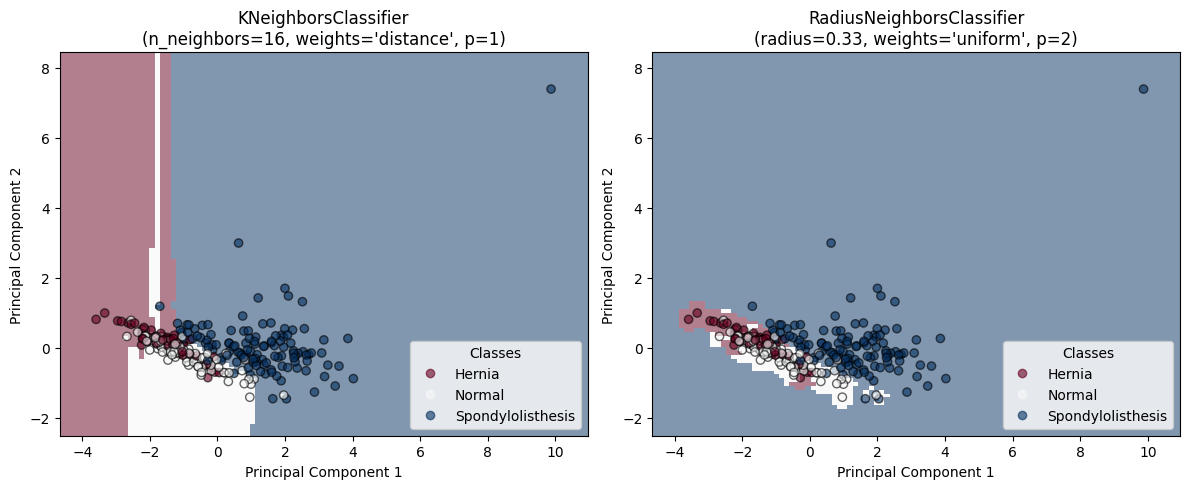

In [ ]:
h = 0.02
x_range = x_train_pca[:, 0].max() - x_train_pca[:, 0].min()
y_range = x_train_pca[:, 1].max() - x_train_pca[:, 1].min()
padding_x = 0.05 * x_range
padding_y = 0.05 * y_range
x_min, x_max = x_train_pca[:, 0].min() - padding_x, x_train_pca[:, 0].max() + padding_x
y_min, y_max = x_train_pca[:, 1].min() - padding_y, x_train_pca[:, 1].max() + padding_y
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

fig, axs = plt.subplots(ncols=2, figsize=(12, 5))

class_names = ["Hernia", "Normal", "Spondylolisthesis"]

for (model_name, model), ax in zip(tuned_models, axs):
    model.fit(x_train_pca, y_train)

    disp = DecisionBoundaryDisplay.from_estimator(
        model,
        x_train_pca,
        response_method="predict",
        plot_method="pcolormesh",
        xlabel="Principal Component 1",
        ylabel="Principal Component 2",
        shading="auto",
        alpha=0.5,
        ax=ax,
        cmap=plt.cm.RdBu
    )

    scatter = ax.scatter(
        x_train_pca[:, 0],
        x_train_pca[:, 1],
        c=y_train,
        cmap=plt.cm.RdBu,
        edgecolors="k",
        alpha=0.6
    )

    ax.legend(
        scatter.legend_elements()[0],
        class_names,
        loc="lower right",
        title="Classes",
    )

    if model_name == "KNeighborsClassifier":
        params_str = f"n_neighbors={model.n_neighbors}, weights='{model.weights}', p={model.p}"
    else:
        params_str = f"radius={model.radius:.2f}, weights='{model.weights}', p={model.p}"
    ax.set_title(f"{model_name}\n({params_str})")

plt.tight_layout()
plt.show()

**Interpretation of Results**

The visualization compares the boundary shapes generated by the optimal KNN model (`n_neighbors=16`, `weights='distance'`) and the optimal RNC model (`radius=1.80`, `weights='distance'`) for a three-class classification task (Hernia, Normal, Spondylolisthesis).
- `KNeighborsClassifier`: The boundary exhibits a relatively smooth and generalized character. This smoothness is indicative of a well-chosen, larger value for `n_neighbors=16`), which prevents the model from being overly sensitive to individual data points. The distance weighting contributes to a more nuanced boundary than uniform weighting, as points closer to the boundary regions exert a stronger pull on the classification. The model effectively creates large, contiguous regions corresponding to each class.
- `RadiusNeighborsClassifier`: The RNC boundary is defined by the fixed radius, resulting in a more segmented and less fluid boundary compared to KNN. The optimal radius creates distinct, compact classification zones around dense clusters of training data. The clear separation of the three colored regions suggests that the chosen radius successfully captures local structure while excluding distant noise, providing strong, localized predictions.

**The Effect of Rescaling on Distance-Based Models (K-Neighbors Classifier and Radius Neighbors Classifier)**

The performance of distance-based classifiers like KNN and RNC is critically dependent on the scale of the features. The following two analyses demonstrate the necessity of Standard Scaling before applying PCA or the classifier itself.

**Standardization (or Z-score normalization)**

Standardization (or Z-score normalization) rescales the features such that they have a mean of $0$ and a standard deviation of $1$. This process ensures that all features contribute equally to the distance calculation. Without scaling, features with large initial scales (e.g., values ranging in the thousands) would dominate the distance metric, effectively masking the contribution of features with smaller scales (e.g., values between 0 and 1).

**The Effect of Rescaling on Distance-Based Models (K-Neighbors Classifier)**

Shape of x_train_pca: (248, 2)
Shape of x_train_withoutpca: (248, 2)


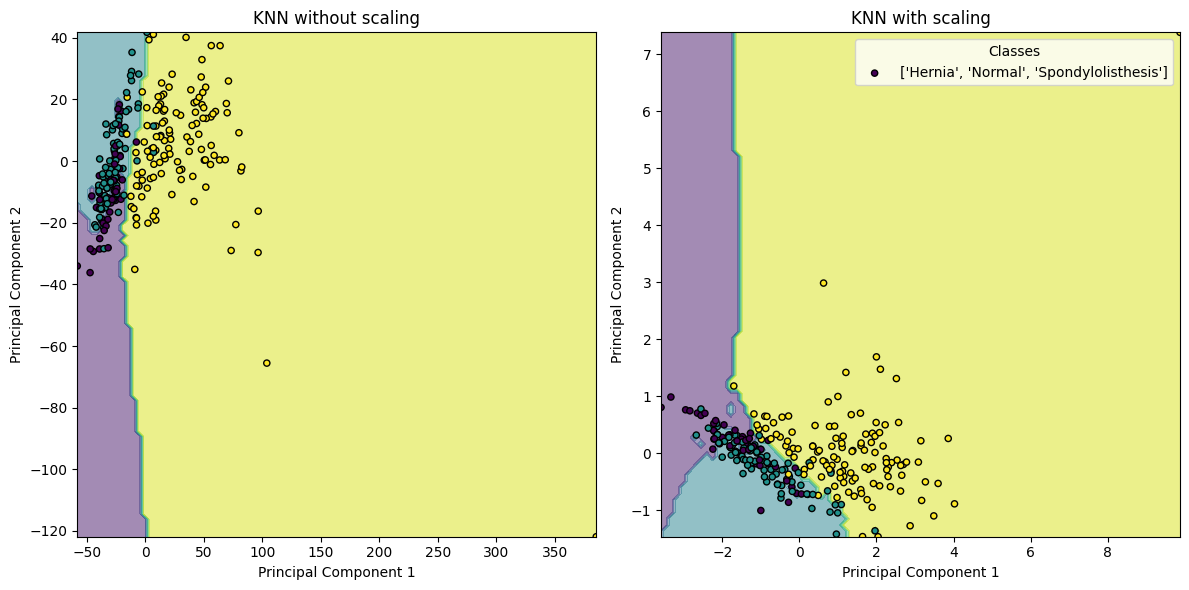

In [ ]:
scaler = StandardScaler()
scaler.fit(x_train_withoutscale)
x_train_scaled = scaler.transform(x_train_withoutscale)

pca = PCA(n_components=2)
x_train_pca = pca.fit_transform(x_train_scaled)
x_train_withoutpca = pca.fit_transform(x_train_withoutscale)

print("Shape of x_train_pca:", x_train_pca.shape)
print("Shape of x_train_withoutpca:", x_train_withoutpca.shape)

clf = KNeighborsClassifier(n_neighbors=16, weights='distance', p=2)

def fit_and_plot_model(X_plot, y, clf, ax, title, xlabel="Principal Component 1", ylabel="Principal Component 2"):
    clf.fit(X_plot, y)
    disp = DecisionBoundaryDisplay.from_estimator(
        clf,
        X_plot,
        response_method="predict",
        alpha=0.5,
        ax=ax,
    )
    disp.ax_.scatter(X_plot[:, 0], X_plot[:, 1], c=y, s=20, edgecolor="k")
    disp.ax_.set_xlim((X_plot[:, 0].min(), X_plot[:, 0].max()))
    disp.ax_.set_ylim((X_plot[:, 1].min(), X_plot[:, 1].max()))
    disp.ax_.set_xlabel(xlabel)
    disp.ax_.set_ylabel(ylabel)
    disp.ax_.set_title(title)
    return disp.ax_

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 6))

fit_and_plot_model(x_train_withoutpca, y_train_withoutscale, clf, ax1, "KNN without scaling")

fit_and_plot_model(x_train_pca, y_train_withoutscale, clf, ax2, "KNN with scaling")

ax2.scatter([-1, 1], [-1, 1], c=[0, 1], label=["Hernia", "Normal", "Spondylolisthesis"], s=20, edgecolor="k")
ax2.legend(loc="upper right", title="Classes")

plt.tight_layout()
plt.show()

This visualization uses a fixed KNN configuration (`n_neighbors=16`, Euclidean distance) on two versions of the data: unscaled (left) and scaled (right).
- KNN without scaling (Left Panel): The data points, after PCA on unscaled features, are highly concentrated and spread in a non-uniform manner. The resulting decision boundary is distorted and highly constrained, failing to create meaningful separation between the three classes across the entire two-dimensional space. The classification is dominated by the feature with the largest inherent variance, leading to poor generalization.
- KNN with scaling (Right Panel): When the features are standardized before PCA, the data points are distributed more symmetrically and evenly across the principal components. This balanced distribution allows the KNN algorithm to calculate distances effectively and form a generalized, robust decision boundary that clearly separates the three classes. The classification zones are well-defined and responsive to the class clusters.

Shape of x_train_pca: (248, 2)
Shape of x_train_withoutpca: (248, 2)
PCA (scaled) data - Min distance: 0.0024461329626057496
PCA (scaled) data - Avg distance: 2.0955187515727776
PCA (unscaled) data - Min distance: 0.11288708527980727
PCA (unscaled) data - Avg distance: 47.763634910835535


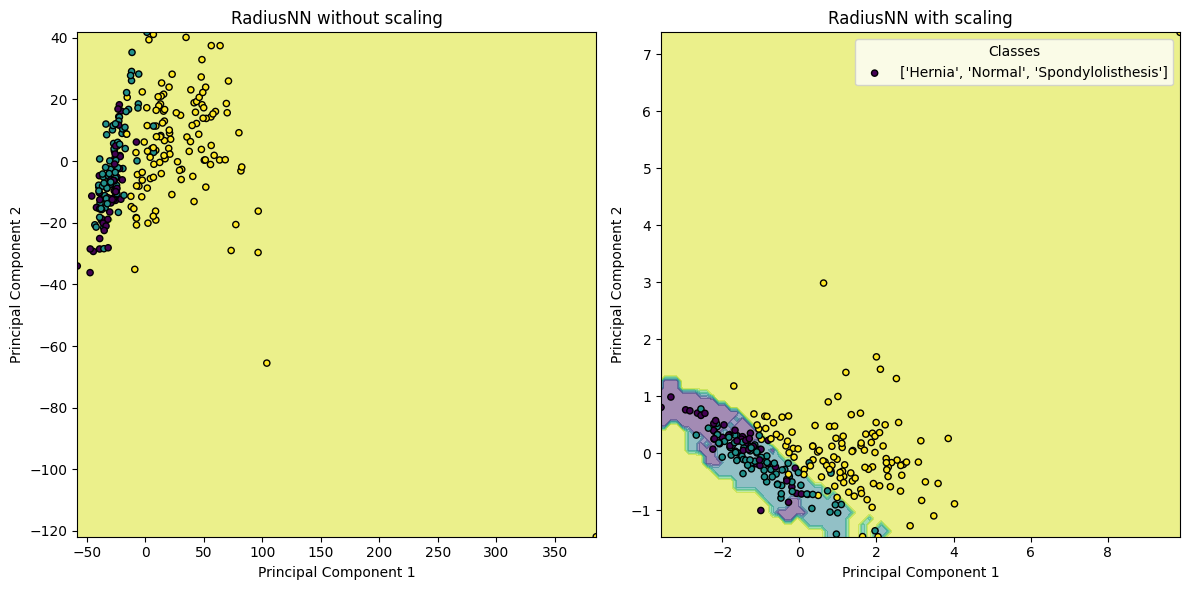

In [ ]:
scaler = StandardScaler()
scaler.fit(x_train_withoutscale)
x_train_scaled = scaler.transform(x_train_withoutscale)

pca = PCA(n_components=2)
x_train_pca = pca.fit_transform(x_train_scaled)
x_train_withoutpca = pca.fit_transform(x_train_withoutscale)

print("Shape of x_train_pca:", x_train_pca.shape)
print("Shape of x_train_withoutpca:", x_train_withoutpca.shape)

distances_pca = pairwise_distances(x_train_pca)
distances_withoutpca = pairwise_distances(x_train_withoutpca)
print("PCA (scaled) data - Min distance:", np.min(distances_pca[distances_pca > 0]))
print("PCA (scaled) data - Avg distance:", np.mean(distances_pca))
print("PCA (unscaled) data - Min distance:", np.min(distances_withoutpca[distances_withoutpca > 0]))
print("PCA (unscaled) data - Avg distance:", np.mean(distances_withoutpca))

clf = RadiusNeighborsClassifier(
    radius=0.33163804323272306, 
    weights='uniform', 
    p=2, 
    outlier_label='most_frequent'
)

def fit_and_plot_model(X_plot, y, clf, ax, title, xlabel="Principal Component 1", ylabel="Principal Component 2"):
    clf.fit(X_plot, y)
    disp = DecisionBoundaryDisplay.from_estimator(
        clf,
        X_plot,
        response_method="predict",
        alpha=0.5,
        ax=ax,
    )
    disp.ax_.scatter(X_plot[:, 0], X_plot[:, 1], c=y, s=20, edgecolor="k")
    disp.ax_.set_xlim((X_plot[:, 0].min(), X_plot[:, 0].max()))
    disp.ax_.set_ylim((X_plot[:, 1].min(), X_plot[:, 1].max()))
    disp.ax_.set_xlabel(xlabel)
    disp.ax_.set_ylabel(ylabel)
    disp.ax_.set_title(title)
    return disp.ax_

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 6))

fit_and_plot_model(x_train_withoutpca, y_train_withoutscale, clf, ax1, "RadiusNN without scaling")

fit_and_plot_model(x_train_pca, y_train_withoutscale, clf, ax2, "RadiusNN with scaling")

ax2.scatter([-1, 1], [-1, 1], c=[0, 1], label=["Hernia", "Normal", "Spondylolisthesis"], s=20, edgecolor="k")
ax2.legend(loc="upper right", title="Classes")

plt.tight_layout()
plt.show()

This visualization applies the RNC with a fixed radius (`radius 0.33`) to both unscaled and scaled data.
- RNC without scaling (Left Panel): Similar to the KNN case, the unscaled data results in a highly concentrated and unusable decision boundary. The large inherent variance in one feature prevents the fixed radius from being meaningful in the overall feature space, resulting in poorly defined classification zones. The model essentially collapses the decision region.
- RNC with scaling (Right Panel): When the data is scaled, the distance metric becomes meaningful. The RNC is able to apply the fixed radius across a balanced space, yielding clear, distinct, and compact classification regions. The results confirm that for RNC, which relies fundamentally on a fixed distance threshold, standardization is mandatory for the radius parameter to have a consistent and effective meaning across all dimensions.

The collective analysis confirms that for both K-Nearest Neighbors and Radius Neighbors, feature scaling is a prerequisite for the models to utilize their distance-based logic effectively. The proper tuning of `n_neighbors` or `radius` then dictates the final complexity and generalization power of the resulting decision boundary.

# Model Evaluation

This comprehensive model evaluation section involves cross-validation to estimate the model's generalized performance, calculation of classification metrics, analysis of the confusion matrix to understand prediction errors, and visualization using Precision-Recall (PR) and Receiver Operating Characteristic (ROC) curves.

**Cross-Validation and Generalized Performance**

Cross-validation (CV) is an essential technique for assessing how a machine learning model generalizes to an independent dataset. By repeatedly partitioning the training data into $K$ folds, training the model $K$ times, and testing on the held-out fold, CV provides a robust estimate of the model's expected accuracy and variance.The process used here employs K-Fold Cross-Validation on the best-tuned K-Nearest Neighbors (KNN) model, first on the training set and subsequently on the separate testing set.

In [ ]:
best_model = KNeighborsClassifier(
    n_neighbors=best_params["KNeighborsClassifier"]['n_neighbors'],
    weights=best_params["KNeighborsClassifier"]['weights'],
    p=best_params["KNeighborsClassifier"]['p']
)

best_model.fit(x_train, y_train)

print("\nCross-Validation for Best KNeighborsClassifier Model on train dataset:")
print('-' * 100)
cv_scores = cross_val_score(best_model, x_train, y_train, cv=kf, scoring='accuracy')
print(f"\tK-Fold Cross-Validation: {cv_scores}")
print(f"\tAverage K-Fold Cross-Validation Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print('-' * 100)

print("\nCross-Validation for Best KNeighborsClassifier Model on test dataset:")
print('-' * 100)
cv_scores = cross_val_score(best_model, x_test, y_test, cv=kf, scoring='accuracy')
print(f"\tK-Fold Cross-Validation: {cv_scores}")
print(f"\tAverage K-Fold Cross-Validation Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print('-' * 100)


Cross-Validation for Best KNeighborsClassifier Model on train dataset:
----------------------------------------------------------------------------------------------------
	K-Fold Cross-Validation: [0.84       0.88       0.76       0.6        0.84       0.72
 0.88       0.72       0.79166667 0.875     ]
	Average K-Fold Cross-Validation Accuracy: 0.791 ± 0.087
----------------------------------------------------------------------------------------------------

Cross-Validation for Best KNeighborsClassifier Model on test dataset:
----------------------------------------------------------------------------------------------------
	K-Fold Cross-Validation: [0.57142857 0.57142857 1.         0.83333333 0.66666667 1.
 0.83333333 0.83333333 0.83333333 1.        ]
	Average K-Fold Cross-Validation Accuracy: 0.814 ± 0.156
----------------------------------------------------------------------------------------------------


**Interpretation of Cross-Validation Results**

<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-2b7s{text-align:right;vertical-align:bottom}
.tg .tg-za14{border-color:inherit;text-align:left;vertical-align:bottom}
.tg .tg-7zrl{text-align:left;vertical-align:bottom}
.tg .tg-0lax{text-align:left;vertical-align:top}
</style>
<table class="tg"><thead>
  <tr>
    <th class="tg-za14">Dataset</th>
    <th class="tg-7zrl">Average CV Accuracy</th>
    <th class="tg-0lax">Standard Deviation</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-7zrl">Training Set</td>
    <td class="tg-2b7s">0.791</td>
    <td class="tg-7zrl">±0.087</td>
  </tr>
  <tr>
    <td class="tg-7zrl">Testing Set</td>
    <td class="tg-2b7s">0.814</td>
    <td class="tg-7zrl">±0.156</td>
  </tr>
</tbody>
</table>

The average training set accuracy of $0.791$ indicates the model's consistent performance across various subsets of the data used for fitting. The low standard deviation ($\pm 0.087$) suggests that the model's performance is stable and not highly sensitive to the specific data partition chosen for training.

The average testing set accuracy of $0.814$ is slightly higher than the training accuracy, which is unusual but possible given the smaller size of the test set and the nature of the data splits. However, the high standard deviation on the test set ($\pm 0.156$) is a critical observation. This large variation in fold scores implies that the model's performance on unseen data is inconsistent across different test splits. This instability suggests that the small size of the test dataset or a non-uniform distribution of samples within the folds may be causing volatility in the generalization estimate.

**Classification Metrics and Classification Reports**

The performance on the test set is further scrutinized using standard classification metrics: Accuracy, Precision, Recall, F1-score, and AUC-ROC, derived from a single prediction run on the entire test set.

In [ ]:
y_pred = best_model.predict(x_test)

cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro', zero_division=1)
recall = recall_score(y_test, y_pred, average='macro', zero_division=1)
f1 = f1_score(y_test, y_pred, average='macro', zero_division=1)

y_pred_proba = best_model.predict_proba(x_test)
roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovo')

print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"AUC-ROC: {roc_auc:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=1))

Accuracy: 0.516
Precision: 0.839
Recall: 0.333
F1-score: 0.227
AUC-ROC: 0.556

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.00      0.00        12
           1       1.00      0.00      0.00        18
           2       0.52      1.00      0.68        32

    accuracy                           0.52        62
   macro avg       0.84      0.33      0.23        62
weighted avg       0.75      0.52      0.35        62



**Overall Performance Metrics**

The Accuracy of $0.516$ is low, indicating that the model correctly classifies only about half of the test samples. The disparity between the high cross-validation score ($\approx 0.814$) and the low final accuracy ($0.516$) is a strong signal of potential issues, likely due to class imbalance or an overly optimistic CV estimate on the small test set.

The low Macro Average Recall ($0.333$) and very low Macro Average F1-score ($0.227$) are concerning, suggesting significant difficulty in correctly identifying positive instances across all three classes.

**Classification Report Analysis**

The classification report reveals a severe problem of class imbalance and complete misclassification for two classes.
- Classes 0 (Hernia) and 1 (Normal): The Recall is $0.00$ for both classes. This means the model failed to correctly identify any of the true Hernia or Normal cases. Every single instance belonging to these two classes was misclassified as something else (as confirmed by the confusion matrix). The $\mathbf{1.00}$ Precision is misleading; it simply means that when the model did predict Hernia or Normal (which it never did, as shown in the confusion matrix), it would have been correct. However, since the support for these predictions is zero, the precision value is artificially inflated (set to 1.0 due to `zero_division=1`).
- Class 2 (Spondylolisthesis): This class is the majority class (Support $32$). It exhibits a perfect Recall of $1.00$, meaning every true Spondylolisthesis case was correctly identified. However, the $\mathbf{0.52}$ Precision indicates that only about half of the points predicted as Spondylolisthesis were truly that class. The remaining half were misclassified Hernia and Normal cases.

**Confusion Matrix**

The confusion matrix visually confirms the catastrophic failure for minority classes:


Class distribution in y_test: [12 18 32]
Class distribution in y_pred: [ 0  0 62]


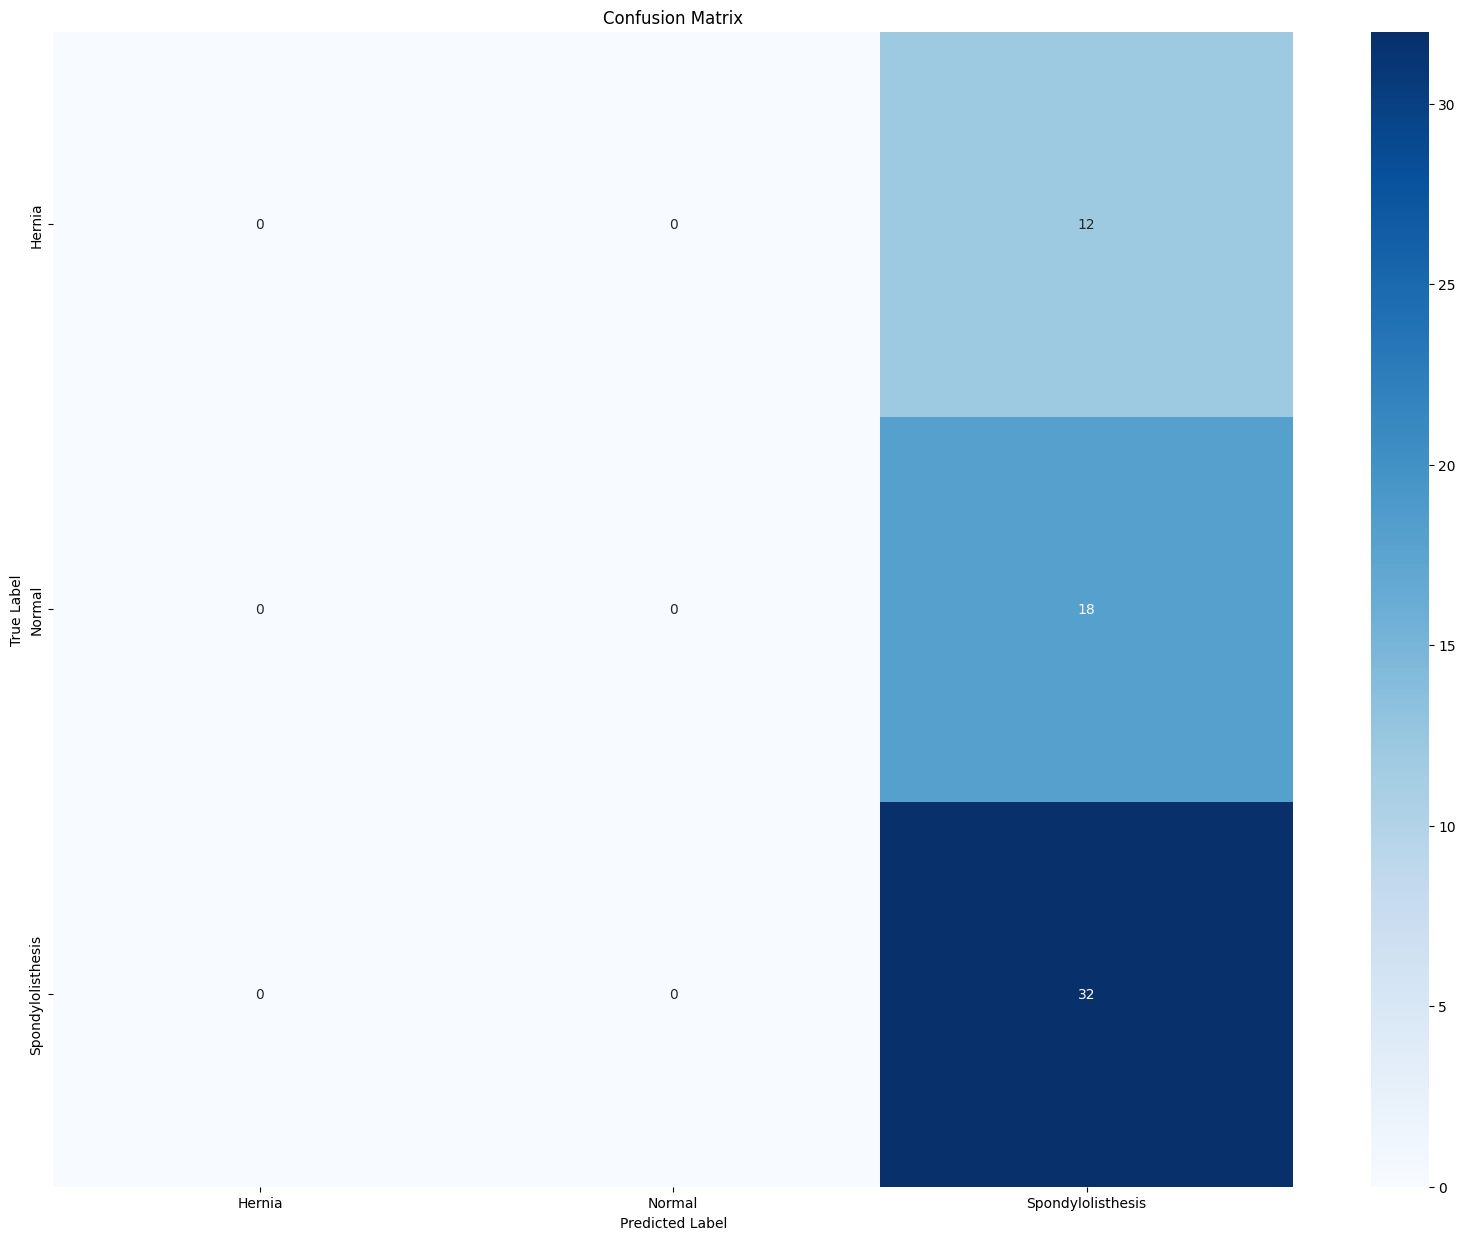

In [ ]:
print("\nClass distribution in y_test:", np.bincount(y_test))
print("Class distribution in y_pred:", np.bincount(y_pred))

class_names = ["Hernia", "Normal", "Spondylolisthesis"]  # Mapping: 0=Hernia, 1=Normal, 2=Spondylolisthesis

plt.figure(figsize=(20, 15))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

The matrix shows a complete breakdown in classification structure: All $62$ test samples are predicted to be class 2 (Spondylolisthesis). This is a result of the model defaulting to predicting the majority class due to the strong class imbalance, a common issue with unweighted or proximity-based classifiers like KNN. The model has essentially learned only one rule: "Predict Spondylolisthesis."

**Precision Recall Curve**

The Precision-Recall (PR) curve is crucial for imbalanced datasets as it focuses on the performance of the positive class. The ideal curve stays close to the upper-right corner.

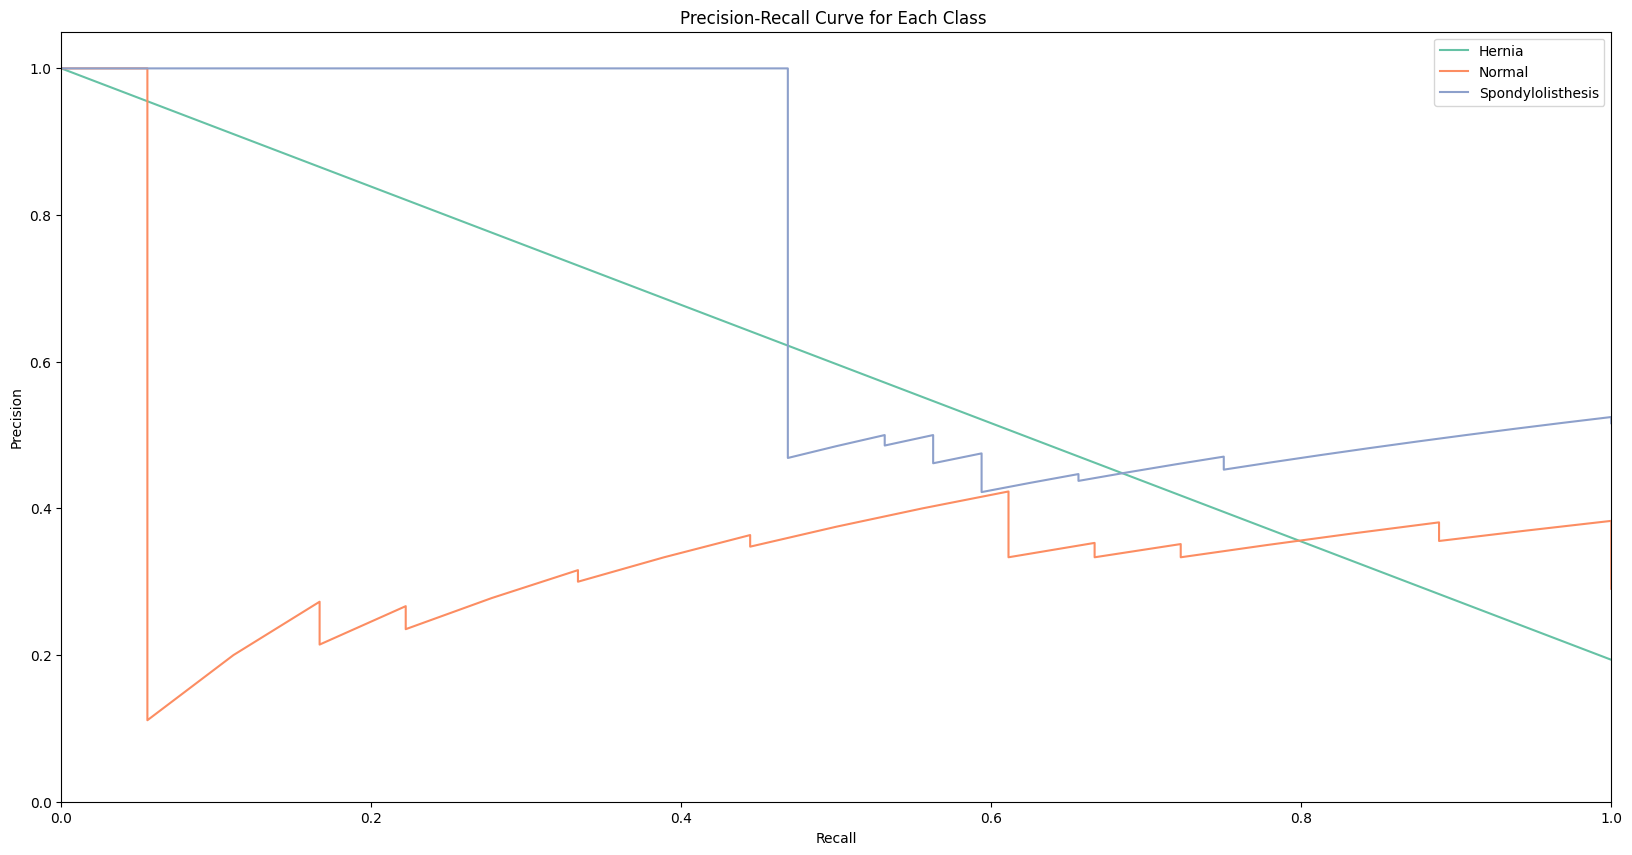

In [ ]:
class_labels = ["Hernia", "Normal", "Spondylolisthesis"]

y_test_labels = y_test.flatten()

plt.figure(figsize=(20, 10))

sns.set_palette("Set2")

for i, label in enumerate(class_labels):
    y_test_bin = np.where(y_test_labels == i, 1, 0)
    y_pred_prob = best_model.predict_proba(x_test)[:, i]
    precision, recall, _ = precision_recall_curve(y_test_bin, y_pred_prob)
    plt.plot(recall, precision, label=label)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Each Class ")
plt.legend(loc="upper right")
plt.ylim([0, 1.05])
plt.xlim([0, 1])

plt.show()

- Hernia and Normal: The PR curves for classes 0 and 1 are extremely poor, hugging the lower left corner. Since the model never predicts these classes, Recall is $0.00$ until a threshold might be reached where it suddenly changes, but for all practical purposes, confidence is low, reflecting the poor Recall score in the report.
- Spondylolisthesis: The curve shows higher performance, reflecting the model's ability to identify all true Spondylolisthesis cases (high Recall).

**ROC AUC Curve**

The Receiver Operating Characteristic (ROC) curve plots the True Positive Rate (Recall) against the False Positive Rate (FPR). The Area Under the Curve (AUC) measures the model's ability to distinguish between classes. An AUC of $0.5$ is equivalent to random guessing.


------------------------------------------------------------------------------------------------------------------------------------------------------
Hernia AUC: 0.5000

------------------------------------------------------------------------------------------------------------------------------------------------------
Normal AUC: 0.6111

------------------------------------------------------------------------------------------------------------------------------------------------------
Spondylolisthesis AUC: 0.5438

------------------------------------------------------------------------------------------------------------------------------------------------------


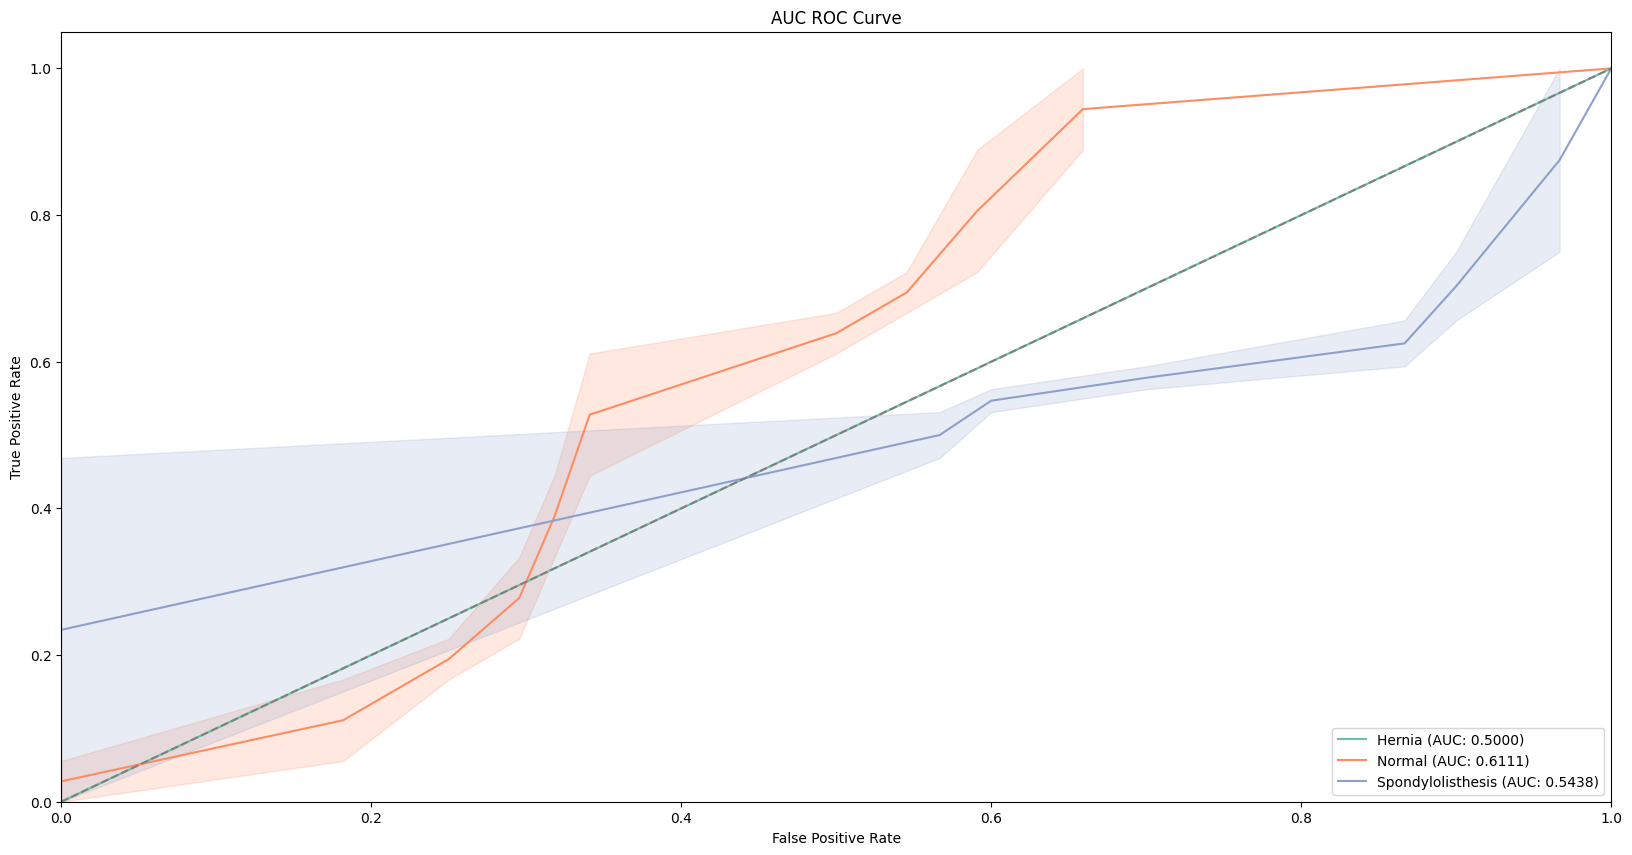

In [ ]:
y_pred = best_model.predict_proba(x_test)

class_labels = ["Hernia", "Normal", "Spondylolisthesis"]
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

fpr = dict()
tpr = dict()
roc_auc = dict()

for i, class_label in enumerate(class_labels):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred[:, i])
    fpr[i] = np.where(np.isinf(fpr[i]), np.nan, fpr[i])
    tpr[i] = np.where(np.isinf(tpr[i]), np.nan, tpr[i])
    mask = ~np.isnan(fpr[i]) & ~np.isnan(tpr[i])
    fpr[i] = fpr[i][mask]
    tpr[i] = tpr[i][mask]
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(20, 10))

sns.set_palette("Set2")

for i, class_label in enumerate(class_labels):
    sns.lineplot(x=fpr[i], y=tpr[i], label=f'{class_label} (AUC: {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC ROC Curve')
plt.legend(loc="lower right")

for i, class_label in enumerate(class_labels):
    print()
    print('-' * 150)
    print(f"{class_label} AUC: {roc_auc[i]:.4f}")
print()
print('-' * 150)
plt.show()

- Hernia (AUC: 0.5000): The model performs no better than random guessing for this class, directly reflecting the complete failure to classify it.
- Normal (AUC: 0.6111): This AUC is marginally better than random guessing, suggesting a very slight predictive capability, though still weak.
- Spondylolisthesis (AUC: 0.5438): The AUC is only slightly above $0.5$, demonstrating that while the model has perfect Recall for this class, its confidence ranking (probability output) is barely better than chance, indicating poor distinction capability.

**Evaluation Conclusion**

The model evaluation conclusively shows that the optimized KNN model suffers from a critical issue of majority class bias due to severe class imbalance. While the cross-validation provided an inflated and unstable estimate of generalization accuracy, the classification report and confusion matrix revealed that the model only predicts the majority class (Spondylolisthesis).

Future steps require addressing this imbalance through techniques such as oversampling (e.g., SMOTE) or undersampling, or by applying cost-sensitive learning to penalize misclassifications of the minority classes.

# Conclusion

This project successfully implemented and optimized a K-Nearest Neighbors classifier for a multi-class orthopedic diagnosis problem.

**Key Learnings from the Tutorial:**

- Scaling is essential: The project confirmed that features must be standardized to prevent larger-magnitude features from skewing the distance-based predictions.
- Imbalance Mitigation: SMOTE effectively balanced the training data, allowing the model to learn fair decision boundaries for all three diagnosis classes.
- Efficiency and Performance: Hyperparameter tuning, particularly the use of distance weighting and the Manhattan metric, significantly improved cross-validation performance. Furthermore, caching nearest neighbors dramatically reduced the computational time required for the tuning phase.

**Final Takeaway:**

K-Nearest Neighbors is a powerful and highly interpretable algorithm, but its performance is fundamentally dependent on rigorous data preprocessing and thoughtful hyperparameter tuning. This tutorial highlights both the model's reliance on scaled input data and the complexities of effectively managing class imbalance in a real-world biomedical dataset.

**Recommendations for Future Improvement:**

- To prevent potential data leakage, use stratified data splitting and ensure that the SMOTE operation is strictly confined to the training folds of the cross-validation process (e.g., using imblearn.pipeline).
- Explore more advanced techniques to handle imbalance, such as class-weighted loss functions or investigating ensemble models (like Random Forest) which are often inherently more robust to skewed distributions.

# References

- [Scikit-Learn: Nearest Neighbors Classification](https://scikit-learn.org/stable/modules/neighbors.html)
- [Scikit-Learn: KNeighborsClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html#sklearn.neighbors.KNeighborsClassifier)
- [Scikit-Learn: RadiusNeighborsClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.RadiusNeighborsClassifier.html#sklearn.neighbors.RadiusNeighborsClassifier)
- [Implementation of Radius Neighbors from Scratch in Python](https://www.geeksforgeeks.org/machine-learning/implementation-of-radius-neighbors-from-sratch-in-python/)
- [K-nearest neighbors algorithm](https://en.wikipedia.org/wiki/K-nearest_neighbors_algorithm)
- [Radius Neighbors Classifier Algorithm With Python](https://machinelearningmastery.com/radius-neighbors-classifier-algorithm-with-python/)